#1.Load Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df_22 = pd.read_csv('/content/drive/MyDrive/TTCS/Data/diem_thi_thpt_2022.csv', dtype={'sbd': str})
df_23 = pd.read_csv('/content/drive/MyDrive/TTCS/Data/diem_thi_thpt_2023.csv', dtype={'sbd': str})
df_24 = pd.read_csv('/content/drive/MyDrive/TTCS/Data/diem_thi_thpt_2024.csv', dtype={'sbd': str})

In [ ]:
df_22.head()

,sbd,toan,ngu_van,ngoai_ngu,vat_li,hoa_hoc,sinh_hoc,lich_su,dia_li,gdcd
0,01000001,3.6,5.00,4.0,NaN,NaN,NaN,2.75,6.0,8.75
1,01000002,8.4,6.75,7.6,NaN,NaN,NaN,8.50,7.5,8.25
2,01000003,5.8,7.50,5.0,NaN,NaN,NaN,7.25,5.5,8.75
3,01000004,7.4,7.50,8.6,NaN,NaN,NaN,7.50,6.5,7.50
4,01000005,7.2,8.50,9.0,NaN,NaN,NaN,8.00,8.5,8.25


In [ ]:
df_23.head()

,sbd,toan,ngu_van,ngoai_ngu,vat_li,hoa_hoc,sinh_hoc,lich_su,dia_li,gdcd,ma_ngoai_ngu
0,01000001,8.4,8.50,9.2,NaN,NaN,NaN,6.75,6.00,9.00,N1
1,01000002,7.2,8.50,9.2,NaN,NaN,NaN,8.75,6.50,8.50,N1
2,01000003,NaN,6.50,NaN,NaN,NaN,NaN,9.25,7.50,NaN,NaN
3,01000004,7.8,8.25,7.8,NaN,NaN,NaN,4.50,6.25,8.25,N1
4,01000005,7.2,8.00,7.8,NaN,NaN,NaN,4.75,6.75,8.25,N1


In [ ]:
df_24.head()

,sbd,toan,ngu_van,ngoai_ngu,vat_li,hoa_hoc,sinh_hoc,lich_su,dia_li,gdcd,ma_ngoai_ngu
0,01000001,8.4,6.75,8.0,6.0,5.25,5.0,NaN,NaN,NaN,N1
1,01000002,8.6,8.50,7.2,NaN,NaN,NaN,7.25,6.00,8.00,N1
2,01000003,8.2,8.75,8.2,NaN,NaN,NaN,7.25,7.25,8.75,N1
3,01000004,4.8,8.50,7.4,NaN,NaN,NaN,7.00,6.00,7.50,N1
4,01000005,8.6,9.00,7.8,NaN,NaN,NaN,9.00,8.75,8.50,N1


#2.Data cleaning

In [ ]:
df_23.drop('ma_ngoai_ngu', axis=1, inplace=True)
df_24.drop('ma_ngoai_ngu', axis=1, inplace=True)

In [ ]:
df_22['year'] = '2022'
df_23['year'] = '2023'
df_24['year'] = '2024'

In [ ]:
df_data = pd.concat([df_22, df_23, df_24],ignore_index=True)

In [ ]:
df_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3079106 entries, 0 to 3079105
Data columns (total 11 columns):
 #   Column     Dtype  
---  ------     -----  
 0   sbd        object 
 1   toan       float64
 2   ngu_van    float64
 3   ngoai_ngu  float64
 4   vat_li     float64
 5   hoa_hoc    float64
 6   sinh_hoc   float64
 7   lich_su    float64
 8   dia_li     float64
 9   gdcd       float64
 10  year       object 
dtypes: float64(9), object(2)
memory usage: 258.4+ MB


In [ ]:
df_data['year'] = df_data['year'].astype(int)

# 3.Analyze

##3.1 Overview

### Số lượng thí sinh từng năm

In [ ]:
# tính số lượng thí sinh mỗi năm
students_per_year = df_data['year'].value_counts().sort_index()
students_per_year

,count
year,
2022,995441
2023,1022060
2024,1061605


In [ ]:
# tính tỉ lệ tăng trưởng
growth_rate = students_per_year.pct_change() * 100
growth_rate

,count
year,
2022,NaN
2023,2.674091
2024,3.869147


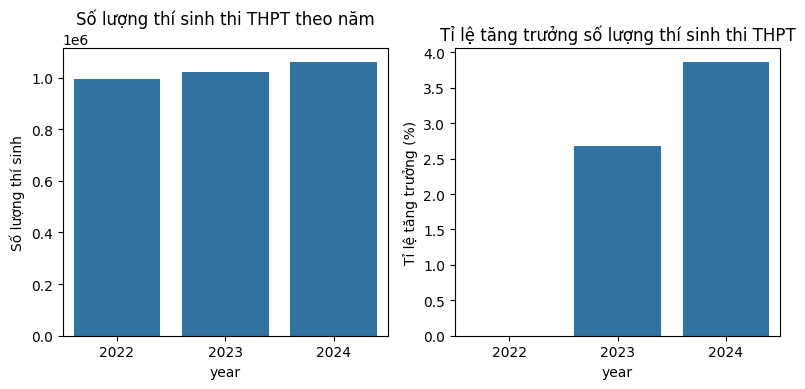

In [ ]:
# tạo DF hiển thị kết quả
students_growth = pd.DataFrame(
    {'Số lượng thí sinh': students_per_year,
     'Tỉ lệ tăng trưởng (%)': growth_rate
     }).reset_index()

# vẽ biểu đồ
fix, ax = plt.subplots(1,2,figsize=(8, 4))

# vẽ số lượng thí sinh
sns.barplot(x='year', y='Số lượng thí sinh', data=students_growth, ax=ax[0])
ax[0].set_title('Số lượng thí sinh thi THPT theo năm')

# vẽ tỉ lệ tăng trưởng
sns.barplot(x='year', y='Tỉ lệ tăng trưởng (%)', data=students_growth, ax=ax[1])
ax[1].set_title('Tỉ lệ tăng trưởng số lượng thí sinh thi THPT')

plt.tight_layout()
plt.show()

*   **Số lượng thí sinh**: Số lượng thí sinh tham gia kỳ thi THPT Quốc gia đã tăng đều qua từng năm từ 2022 đến 2024. Cụ thể, số lượng thí sinh là 995.441 vào năm 2022, 1.022.060 vào năm 2023 và 1.061.605 vào năm 2024.
*   **Tốc độ tăng trưởng**: Tốc độ tăng trưởng số lượng thí sinh cũng cho thấy xu hướng tăng lên. Tỉ lệ tăng trưởng là 2.67% vào năm 2023 so với năm 2022, và tăng lên 3.87% vào năm 2024 so với năm 2023.



### Điểm các môn theo từng năm

<Figure size 1000x600 with 0 Axes>

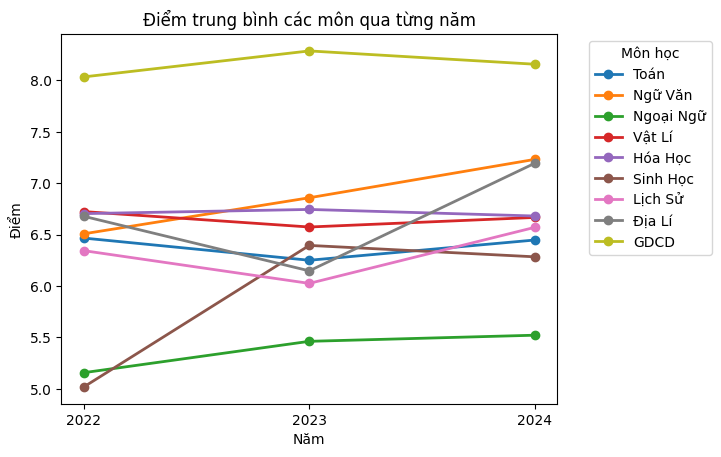

In [ ]:
subjects = ['toan','ngu_van','ngoai_ngu','vat_li','hoa_hoc','sinh_hoc','lich_su','dia_li','gdcd']
titles = ['Toán','Ngữ Văn','Ngoại Ngữ','Vật Lí','Hóa Học','Sinh Học','Lịch Sử','Địa Lí','GDCD']

# Tính điểm trung bình
mean_scores = df_data.groupby('year')[subjects].mean()

# Vẽ biểu đồ
plt.figure(figsize=(10,6))
mean_scores.plot(marker='o', linewidth=2)

plt.title('Điểm trung bình các môn qua từng năm')
plt.xlabel('Năm')
plt.ylabel('Điểm')
plt.legend(titles, title='Môn học', bbox_to_anchor=(1.05, 1))
plt.xticks(mean_scores.index)
plt.show()

* **GDCD**: Luôn có điểm trung bình cao nhất trong tất cả các môn và có xu hướng tăng nhẹ qua các năm (từ khoảng 8.01 năm 2022 lên 8.13 năm 2024).
* **Ngữ Văn**: Thể hiện xu hướng tăng trưởng ổn định và đáng kể qua từng năm (từ khoảng 6.51 năm 2022 lên 7.23 năm 2024).
* **Toán, Vật Lý**: Các môn này có xu hướng giảm nhẹ điểm trung bình vào năm 2023 so với 2022, sau đó phục hồi và tăng trở lại vào năm 2024, gần đạt hoặc vượt mức điểm của năm 2022.
* **Lịch Sử, Địa Lý**: Cũng có sự giảm điểm nhẹ vào năm 2023 nhưng sau đó có sự tăng trưởng mạnh mẽ nhất vào năm 2024, đạt mức điểm trung bình cao nhất trong 3 năm.
* **Sinh Học**: Có sự tăng vọt đáng kể về điểm trung bình từ năm 2022 đến 2023, sau đó giảm nhẹ vào năm 2024 nhưng vẫn cao hơn năm 2022.
* **Hóa Học**: Điểm trung bình tương đối ổn định qua các năm với sự biến động nhỏ.
* **Ngoại Ngữ**: Điểm trung bình có xu hướng tăng nhẹ qua các năm, nhưng vẫn là một trong những môn có điểm trung bình thấp hơn so với các môn khác.

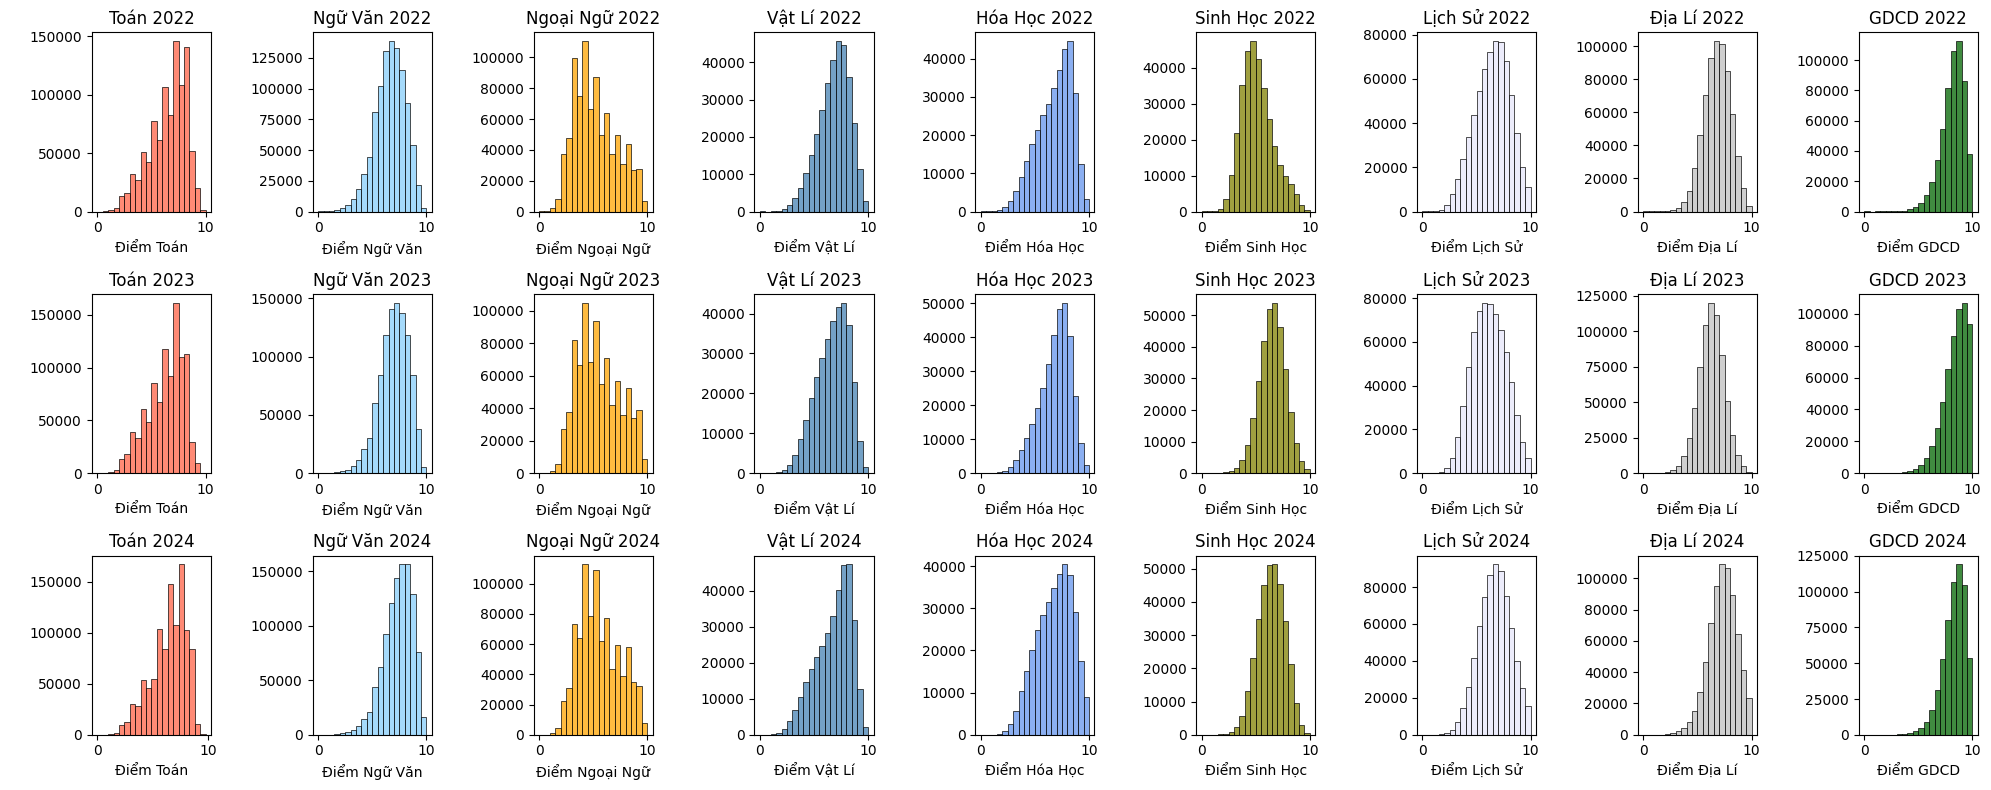

In [ ]:
# phổ điểm các môn qua từng năm
fig, axes = plt.subplots(3,9,figsize=(20,8))
year_sorted = [2022,2023,2024]
colors = ['tomato','lightskyblue','orange','steelblue','cornflowerblue','olive','lavender','silver', 'darkgreen']
for i,year in enumerate(year_sorted):
  for j,(subject,color_val) in enumerate(zip(subjects,colors)):
    sns.histplot(df_data[df_data['year']==year][subject], bins=20, ax=axes[i,j], color=color_val)
    axes[i,j].set_title(f'{titles[j]} {year}')
    axes[i,j].set_xlabel(f'Điểm {titles[j]}')
    axes[i,j].set_ylabel(' ')
plt.tight_layout()
plt.show()

* **Phân bố điểm chung**: Hầu hết các môn đều có phân bố điểm không hoàn toàn đối xứng. Các môn xã hội (Ngữ Văn, Lịch Sử, Địa Lí, GDCD) thường có xu hướng lệch phải, tức là phần lớn thí sinh đạt điểm cao. Ngược lại, các môn tự nhiên (Toán, Vật Lí, Hóa Học, Sinh Học) và Ngoại Ngữ thường có phân bố điểm rộng hơn, và đôi khi lệch trái hoặc có nhiều đỉnh, đặc biệt là Ngoại Ngữ.

* **Điểm cao tập trung ở các môn xã hội**:

  * **GDCD**: Luôn có phổ điểm tập trung rất cao ở phía điểm cao (8-10), đặc biệt là đỉnh ở 8-9 điểm, cho thấy đây là môn mà đa số thí sinh làm bài rất tốt. Xu hướng này duy trì ổn định qua các năm.
  * **Ngữ Văn, Lịch Sử, Địa Lí**: Phổ điểm các môn này cũng có xu hướng tập trung ở khoảng 6-8 điểm, với phần đuôi kéo dài về phía điểm thấp hơn. Phổ điểm có vẻ dịch chuyển nhẹ về phía điểm cao hơn qua từng năm, đặc biệt là vào năm 2024, phù hợp với xu hướng điểm trung bình tăng lên.
* **Phân bố điểm các môn tự nhiên**:

  * **Toán, Vật Lí, Hóa Học, Sinh Học**: Các môn này thường có phổ điểm rộng hơn, đỉnh phổ biến ở khoảng 5-7 điểm. Số lượng thí sinh đạt điểm tuyệt đối hoặc điểm rất cao ít hơn đáng kể so với các môn xã hội. Phân bố có thể thay đổi nhỏ giữa các năm, phản ánh sự thay đổi độ khó của đề thi hoặc mặt bằng chung của thí sinh.
  * **Ngoại Ngữ**: Môn Ngoại Ngữ thường có phân bố khá đặc biệt, với một lượng lớn thí sinh đạt điểm thấp (1-4 điểm), tạo thành một đỉnh ở phía thấp, và một đỉnh khác ở các mức điểm trung bình khá (6-8 điểm). Điều này cho thấy sự chênh lệch lớn về trình độ ngoại ngữ của thí sinh.

### Chi tiết từng môn

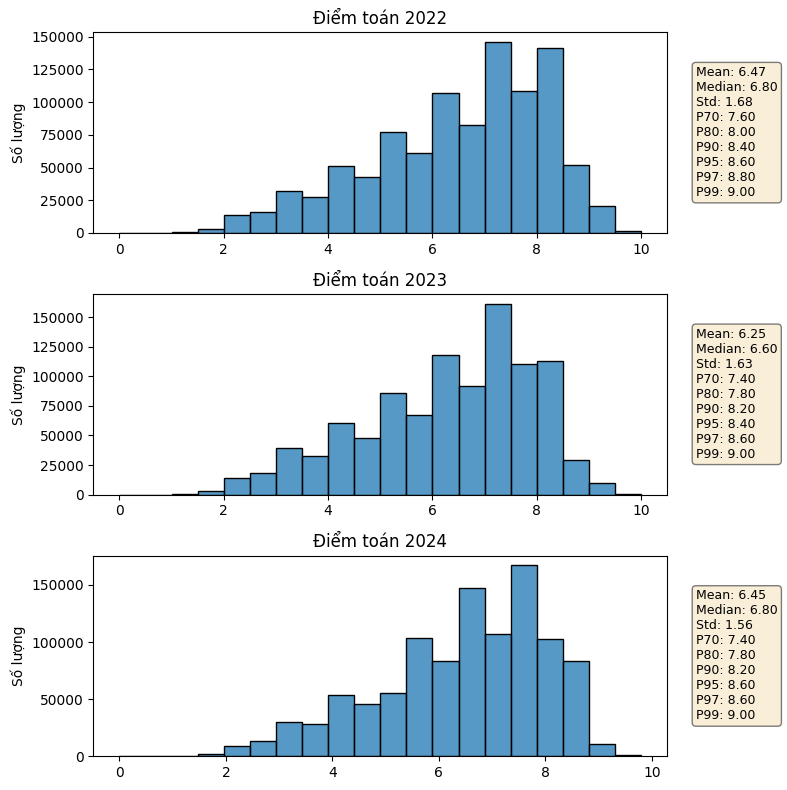

In [ ]:
# toán
from matplotlib import text
fig,axes = plt.subplots(3,1,figsize=(8,8))
for i,year in enumerate(year_sorted):
  sns.histplot(df_data[df_data['year']==year]['toan'], bins=20, ax=axes[i])
  axes[i].set_title(f'Điểm toán {year}')
  axes[i].set_xlabel('')
  axes[i].set_ylabel('Số lượng')
  # tính toán các chỉ số thống kê
  year_toan = df_data[df_data['year']==year]['toan'].dropna()
  mean = year_toan.mean()
  median = year_toan.median()
  std = year_toan.std()
  p70 =  year_toan.quantile(0.7)
  p80 =  year_toan.quantile(0.8)
  p90 =  year_toan.quantile(0.9)
  p95 =  year_toan.quantile(0.95)
  p97 =  year_toan.quantile(0.97)
  p99 =  year_toan.quantile(0.99)
  # hiển thị thông tin thống kê trên biểu đồ
  textstr = f'Mean: {mean:.2f}\nMedian: {median:.2f}\nStd: {std:.2f}\nP70: {p70:.2f}\nP80: {p80:.2f}\nP90: {p90:.2f}\nP95: {p95:.2f}\nP97: {p97:.2f}\nP99: {p99:.2f}'
  prop = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
  axes[i].text(1.05, 0.5, textstr, transform=axes[i].transAxes, fontsize=9, verticalalignment='center', bbox=prop)
plt.tight_layout()
plt.show()

**Năm 2022 (Toán 2022):**

* **Điểm trung bình (Mean)**: 6.47
* **Điểm trung vị (Median)**: 6.8
* **Độ lệch chuẩn (Std)**: 1.68
* **Phân bố**: Phổ điểm có dạng tương đối cân đối, hơi lệch về phía điểm cao hơn một chút, với đỉnh phổ biến nằm trong khoảng 6-7 điểm. Có một lượng đáng kể thí sinh đạt điểm từ 8 trở lên.
* **Nhóm điểm cao**: Các điểm phân vị cho thấy P90 là 8.4, P95 là 8.6, P97 là 8.8 và P99 là 9.0, cho thấy nhóm thí sinh giỏi có điểm khá cao và có độ phân hóa tốt ở nhóm này.

**Năm 2023 (Toán 2023):**

* **Điểm trung bình (Mean)**: 6.25
* **Điểm trung vị (Median)**: 6.6
* **Độ lệch chuẩn (Std)**: 1.63
* **Phân bố**: So với năm 2022, phổ điểm có vẻ dịch chuyển nhẹ về phía điểm thấp hơn. Đỉnh phổ biến vẫn ở khoảng 6-7 điểm nhưng số lượng thí sinh đạt điểm rất cao có phần giảm sút.
* **Nhóm điểm cao**: Các điểm phân vị P90 là 8.2, P95 là 8.4, P97 là 8.6 và P99 là 9.0. Có thể thấy điểm của nhóm thí sinh giỏi cũng giảm nhẹ so với năm 2022.

**Năm 2024 (Toán 2024):**

* **Điểm trung bình (Mean)**: 6.45
* **Điểm trung vị (Median)**: 6.8
* **Độ lệch chuẩn (Std)**: 1.56
* **Phân bố**: Phổ điểm có sự phục hồi đáng kể so với năm 2023, trở về gần với mức của năm 2022. Đỉnh phổ biến vẫn duy trì ở khoảng 6-7 điểm. Độ lệch chuẩn giảm nhẹ cho thấy điểm số có phần tập trung hơn.
* **Nhóm điểm cao**: Các điểm phân vị P90 là 8.2, P95 là 8.6, P97 là 8.6 và P99 là 9.0. Điểm của nhóm thí sinh giỏi cũng có sự cải thiện so với năm 2023, gần tương đương hoặc cao hơn nhẹ so với năm 2022 ở một số ngưỡng.

**Tóm lại về môn Toán:**

* Điểm trung bình và trung vị của môn Toán có sự giảm nhẹ vào năm 2023 so với 2022, sau đó phục hồi gần như hoàn toàn vào năm 2024. Điều này cho thấy độ khó của đề thi hoặc hiệu suất của thí sinh có thể biến động qua từng năm.
* Phân bố điểm qua các năm tương đối ổn định, tập trung chủ yếu ở mức 6-7 điểm, với độ phân hóa tốt ở nhóm điểm cao.
* Độ lệch chuẩn không thay đổi đáng kể, cho thấy sự phân tán của điểm số không có biến động lớn giữa các năm.

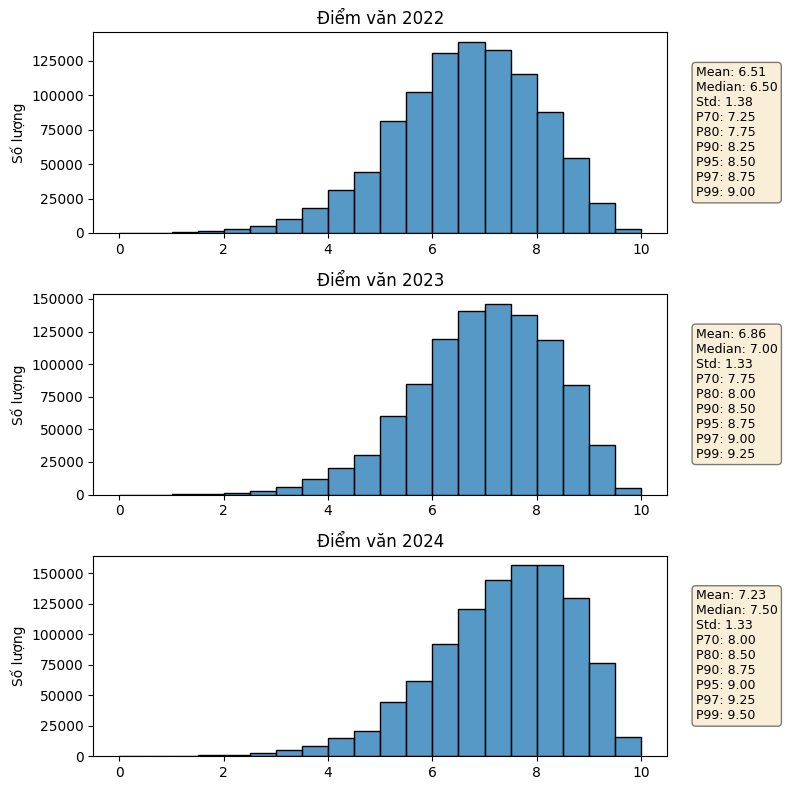

In [ ]:
# ngữ văn
fig,axes = plt.subplots(3,1,figsize=(8,8))
for i,year in enumerate(year_sorted):
  sns.histplot(df_data[df_data['year']==year]['ngu_van'], bins=20, ax=axes[i])
  axes[i].set_title(f'Điểm văn {year}')
  axes[i].set_xlabel('')
  axes[i].set_ylabel('Số lượng')
  # tính toán các chỉ số thống kê
  year_van = df_data[df_data['year']==year]['ngu_van'].dropna()
  mean = year_van.mean()
  median = year_van.median()
  std = year_van.std()
  p70 =  year_van.quantile(0.7)
  p80 =  year_van.quantile(0.8)
  p90 =  year_van.quantile(0.9)
  p95 =  year_van.quantile(0.95)
  p97 =  year_van.quantile(0.97)
  p99 =  year_van.quantile(0.99)
  # hiển thị thông tin thống kê trên biểu đồ
  textstr = f'Mean: {mean:.2f}\nMedian: {median:.2f}\nStd: {std:.2f}\nP70: {p70:.2f}\nP80: {p80:.2f}\nP90: {p90:.2f}\nP95: {p95:.2f}\nP97: {p97:.2f}\nP99: {p99:.2f}'
  prop = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
  axes[i].text(1.05, 0.5, textstr, transform=axes[i].transAxes, fontsize=9, verticalalignment='center', bbox=prop)
plt.tight_layout()
plt.show()

**Năm 2022 (Văn 2022):**

* **Điểm trung bình (Mean)**: 6.51
* **Điểm trung vị (Median)**: 6.5
* **Độ lệch chuẩn (Std)**: 1.38
* **Phân bố**: Phổ điểm có dạng lệch phải, với phần lớn thí sinh đạt điểm khá đến cao, đỉnh phổ biến nằm trong khoảng 6.5-7.5 điểm. Có một số thí sinh đạt điểm rất cao (từ 8.5 trở lên).
* **Nhóm điểm cao**: Các điểm phân vị P70: ~7.25, P80: ~7.75, P90: ~8.25, P95: ~8.5, P97: ~8.75, P99: ~9.0, cho thấy nhóm thí sinh giỏi có điểm cao và khá tập trung.

**Năm 2023 (Văn 2023):**

* **Điểm trung bình (Mean)**: 6.86
* **Điểm trung vị (Median)**: 7.00
* **Độ lệch chuẩn (Std)**: 1.33
* **Phân bố**: So với năm 2022, phổ điểm có vẻ dịch chuyển nhẹ về phía điểm cao hơn. Đỉnh phổ biến nằm trong khoảng 7.0-8.0 điểm. Sự phân bố vẫn giữ dạng lệch phải, cho thấy nhiều thí sinh đạt điểm cao.
* **Nhóm điểm cao**: Các điểm phân vị P70: ~7.75, P80: ~8.0, P90: ~8.5, P95: ~8.75, P97: ~9.0, P99: ~9.25. Điểm của nhóm thí sinh giỏi cũng tăng nhẹ so với năm 2022.

**Năm 2024 (Văn 2024):**

* **Điểm trung bình (Mean)**: 7.23
* **Điểm trung vị (Median)**: 7.50
* **Độ lệch chuẩn (Std)**: 1.33
* **Phân bố**: Phổ điểm tiếp tục dịch chuyển rõ rệt về phía điểm cao hơn so với năm 2023 và 2022. Đỉnh phổ biến nằm trong khoảng 7.5-8.5 điểm. Độ lệch chuẩn giảm nhẹ cho thấy điểm số có phần tập trung hơn ở các mức cao hơn.
* **Nhóm điểm cao**: Các điểm phân vị P70: ~8.0, P80: ~8.5, P90: ~8.75, P95: ~9.0, P97: ~9.25, P99: ~9.5. Nhóm thí sinh giỏi đạt điểm rất cao, với nhiều thí sinh có thể đạt điểm gần tuyệt đối.

**Tóm lại về môn Ngữ Văn:**

* Điểm trung bình và trung vị của môn Ngữ Văn cho thấy xu hướng tăng trưởng ổn định và đáng kể qua từng năm, từ 2022 đến 2024. Điều này có thể cho thấy sự cải thiện trong chất lượng dạy và học môn Ngữ Văn, hoặc đề thi có độ khó phù hợp hơn, hoặc cả hai.
* Phân bố điểm luôn có dạng lệch trái, với phần lớn thí sinh đạt điểm khá và cao, đặc biệt là trong năm 2024. Điều này chứng tỏ môn Ngữ Văn là môn mà nhiều thí sinh có thể đạt được kết quả tốt.
* Độ lệch chuẩn duy trì ở mức tương đối thấp và có xu hướng giảm nhẹ, cho thấy sự đồng đều hơn trong kết quả của thí sinh, đặc biệt ở các nhóm điểm cao.

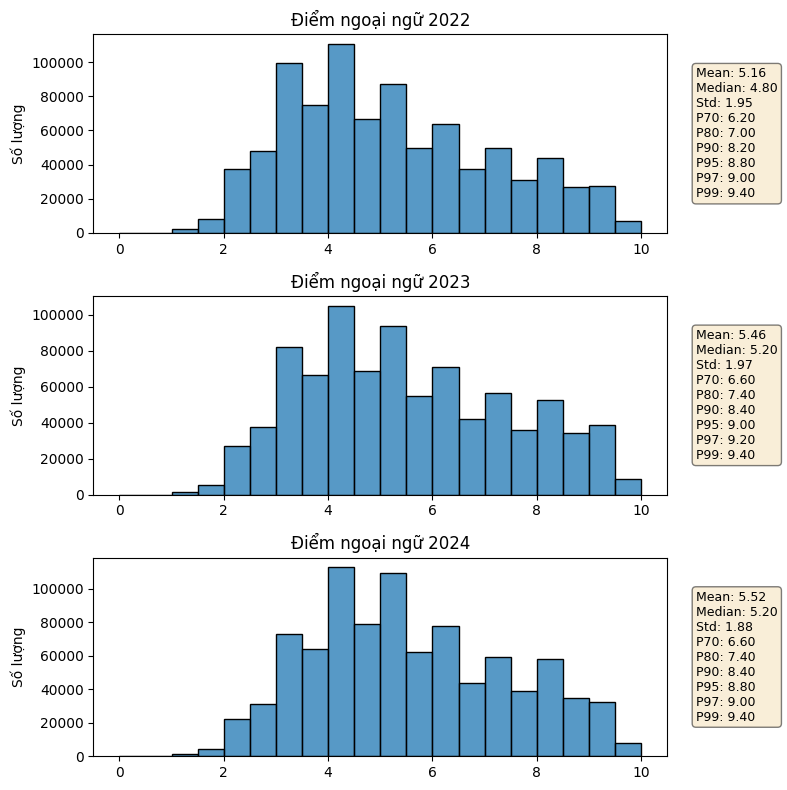

In [ ]:
# ngoại ngữ
fig,axes = plt.subplots(3,1,figsize=(8,8))
for i,year in enumerate(year_sorted):
  sns.histplot(df_data[df_data['year']==year]['ngoai_ngu'], bins=20, ax=axes[i])
  axes[i].set_title(f'Điểm ngoại ngữ {year}')
  axes[i].set_xlabel('')
  axes[i].set_ylabel('Số lượng')
  # tính toán các chỉ số thống kê
  year_nn = df_data[df_data['year']==year]['ngoai_ngu'].dropna()
  mean = year_nn.mean()
  median = year_nn.median()
  std = year_nn.std()
  p70 =  year_nn.quantile(0.7)
  p80 =  year_nn.quantile(0.8)
  p90 =  year_nn.quantile(0.9)
  p95 =  year_nn.quantile(0.95)
  p97 =  year_nn.quantile(0.97)
  p99 =  year_nn.quantile(0.99)
  # hiển thị thông tin thống kê trên biểu đồ
  textstr = f'Mean: {mean:.2f}\nMedian: {median:.2f}\nStd: {std:.2f}\nP70: {p70:.2f}\nP80: {p80:.2f}\nP90: {p90:.2f}\nP95: {p95:.2f}\nP97: {p97:.2f}\nP99: {p99:.2f}'
  prop = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
  axes[i].text(1.05, 0.5, textstr, transform=axes[i].transAxes, fontsize=9, verticalalignment='center', bbox=prop)
plt.tight_layout()
plt.show()

**Năm 2022 (Ngoại Ngữ 2022):**
*   **Điểm trung bình (Mean)**: 5.16
*   **Điểm trung vị (Median)**: 4.8
*   **Độ lệch chuẩn (Std)**: 1.95
*   **Phân bố**: Phổ điểm môn Ngoại Ngữ năm 2022 thể hiện rõ tính chất bimodal (hai đỉnh), với một đỉnh lớn tập trung ở các điểm thấp (khoảng 2-4 điểm) và một đỉnh nhỏ hơn ở các điểm trung bình khá (khoảng 6-7 điểm). Điều này cho thấy sự phân hóa rõ rệt về trình độ ngoại ngữ của thí sinh.
*   **Nhóm điểm cao**: Các điểm phân vị cho thấy P70: ~6.2, P80: ~7.0, P90: ~8.2, P95: ~8.8, P97: ~9.0, P99: ~9.4.

**Năm 2023 (Ngoại Ngữ 2023):**
*   **Điểm trung bình (Mean)**: 5.46
*   **Điểm trung vị (Median)**: 5.2
*   **Độ lệch chuẩn (Std)**: 1.97
*   **Phân bố**: Phổ điểm vẫn giữ hình dạng bimodal, nhưng có xu hướng dịch chuyển nhẹ về phía điểm cao hơn so với năm 2022, phù hợp với sự tăng nhẹ của điểm trung bình. Đỉnh ở nhóm điểm thấp có thể giảm bớt, và đỉnh ở nhóm điểm khá có thể trở nên rõ ràng hơn.
*   **Nhóm điểm cao**: Các điểm phân vị P70: ~6.6, P80: ~7.4, P90: ~8.4, P95: ~9.0, P97: ~9.2, P99: ~9.4.

**Năm 2024 (Ngoại Ngữ 2024):**
*   **Điểm trung bình (Mean)**: 5.52
*   **Điểm trung vị (Median)**: 5.2
*   **Độ lệch chuẩn (Std)**: 1.88
*   **Phân bố**: Phổ điểm tiếp tục cho thấy cấu trúc bimodal đặc trưng của môn Ngoại Ngữ. Mặc dù điểm trung bình có tăng nhẹ so với 2023, đỉnh ở các điểm thấp vẫn tồn tại đáng kể, và đỉnh ở các điểm khá (tầm 7-8 điểm) vẫn hiện diện. Điều này cho thấy vẫn có sự chênh lệch lớn về năng lực ngoại ngữ trong tổng thể thí sinh.
*   **Nhóm điểm cao**: Các điểm phân vị P70: 6.6, P80: 7.4, P90: 8.4, P95: 8.8, P97: 9.0, P99: 9.4. Các ngưỡng điểm cao này ổn định và cho thấy nhóm thí sinh giỏi vẫn giữ được mức điểm tốt.

**Tóm lại về môn Ngoại Ngữ:**
*   Điểm trung bình của môn Ngoại Ngữ có xu hướng tăng nhẹ qua từng năm, từ 5.16 (2022) lên 5.52 (2024), nhưng vẫn là một trong những môn có điểm trung bình thấp hơn so với các môn khác.
*   Phân bố điểm luôn có dạng bimodal, với một lượng lớn thí sinh đạt điểm thấp và một nhóm khác đạt điểm khá. Điều này phản ánh sự phân hóa mạnh mẽ về trình độ ngoại ngữ trong khối thí sinh.
*   Độ lệch chuẩn tương đối cao, cho thấy sự phân tán rộng của điểm số, củng cố nhận định về sự chênh lệch trình độ giữa các thí sinh.

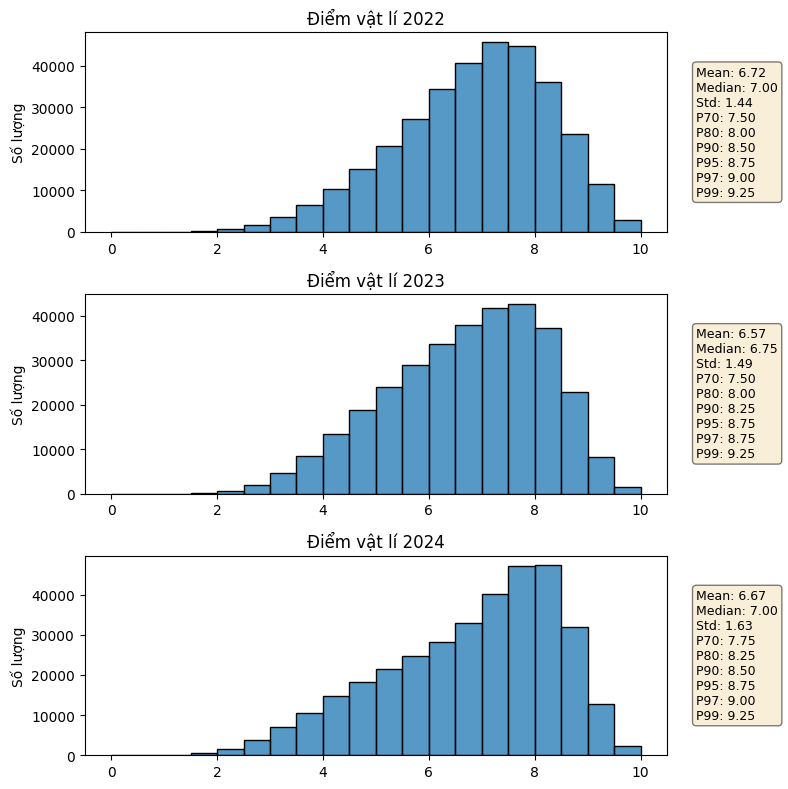

In [ ]:
# vật lí
fig,axes = plt.subplots(3,1,figsize=(8,8))
for i,year in enumerate(year_sorted):
  sns.histplot(df_data[df_data['year']==year]['vat_li'], bins=20, ax=axes[i])
  axes[i].set_title(f'Điểm vật lí {year}')
  axes[i].set_xlabel('')
  axes[i].set_ylabel('Số lượng')
  # tính toán các chỉ số thống kê
  year_li = df_data[df_data['year']==year]['vat_li'].dropna()
  mean = year_li.mean()
  median = year_li.median()
  std = year_li.std()
  p70 =  year_li.quantile(0.7)
  p80 =  year_li.quantile(0.8)
  p90 =  year_li.quantile(0.9)
  p95 =  year_li.quantile(0.95)
  p97 =  year_li.quantile(0.97)
  p99 =  year_li.quantile(0.99)
  # hiển thị thông tin thống kê trên biểu đồ
  textstr = f'Mean: {mean:.2f}\nMedian: {median:.2f}\nStd: {std:.2f}\nP70: {p70:.2f}\nP80: {p80:.2f}\nP90: {p90:.2f}\nP95: {p95:.2f}\nP97: {p97:.2f}\nP99: {p99:.2f}'
  prop = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
  axes[i].text(1.05, 0.5, textstr, transform=axes[i].transAxes, fontsize=9, verticalalignment='center', bbox=prop)
plt.tight_layout()
plt.show()

**Năm 2022 (Vật lí 2022):**
*   **Điểm trung bình (Mean)**: Khoảng 6.72
*   **Điểm trung vị (Median)**: 7.0
*   **Độ lệch chuẩn (Std)**:1.44
*   **Phân bố**: Phổ điểm thường có dạng tương đối cân đối hoặc hơi lệch phải nhẹ, tập trung chủ yếu ở khoảng 6-8 điểm. Có một lượng đáng kể thí sinh đạt điểm khá cao.
*   **Nhóm điểm cao**: Các điểm phân vị cao (P90, P95) cho thấy sự phân hóa tốt ở nhóm thí sinh giỏi.

**Năm 2023 (Vật lí 2023):**
*   **Điểm trung bình (Mean)**: Khoảng 6.57 (giảm nhẹ so với 2022).
*   **Điểm trung vị (Median)**: 6.75, có xu hướng giảm nhẹ.
*   **Độ lệch chuẩn (Std)**: 1.49 cho thấy sự ổn định trong độ phân tán.
*   **Phân bố**: Phổ điểm có xu hướng dịch chuyển nhẹ về phía điểm thấp hơn so với năm 2022, phản ánh sự giảm của điểm trung bình. Đỉnh phổ biến vẫn ở khoảng 6-7 điểm, nhưng số lượng thí sinh đạt điểm rất cao có thể ít hơn.
*   **Nhóm điểm cao**: Các điểm phân vị cao cũng có thể giảm nhẹ, cho thấy nhóm thí sinh giỏi có thể gặp khó khăn hơn một chút hoặc đề thi có độ khó cao hơn.

**Năm 2024 (Vật lí 2024):**
*   **Điểm trung bình (Mean)**: Khoảng 6.67 (phục hồi nhẹ so với 2023, gần bằng 2022).
*   **Điểm trung vị (Median)**: 7.0 có xu hướng phục hồi.
*   **Độ lệch chuẩn (Std)**: 1.67 cho thấy điểm số có phần tập trung hơn.
*   **Phân bố**: Phổ điểm có sự phục hồi, dịch chuyển về gần với mức của năm 2022. Đỉnh phổ biến tiếp tục ở khoảng 6-7 điểm. Số lượng thí sinh đạt điểm cao có thể tăng trở lại.
*   **Nhóm điểm cao**: Các điểm phân vị cao có thể phục hồi, cho thấy nhóm thí sinh giỏi vẫn đạt được kết quả tốt và sự phân hóa được duy trì.

**Tóm lại về môn Vật lí:**
*   Điểm trung bình môn Vật lí có sự biến động nhẹ qua các năm, giảm vào năm 2023 so với 2022 và sau đó phục hồi vào năm 2024, gần đạt mức của năm 2022. Điều này cho thấy độ khó của đề thi hoặc hiệu suất tổng thể của thí sinh có thể thay đổi nhẹ giữa các năm.
*   Phân bố điểm thường tập trung ở mức trung bình khá (6-8 điểm), với độ phân hóa tương đối tốt ở nhóm điểm cao, đặc biệt là vào các năm 2022 và 2024.
*   Độ lệch chuẩn tương đối ổn định, cho thấy sự phân tán của điểm số không có biến động lớn, dù có thể có sự tập trung nhẹ hơn vào năm 2024.

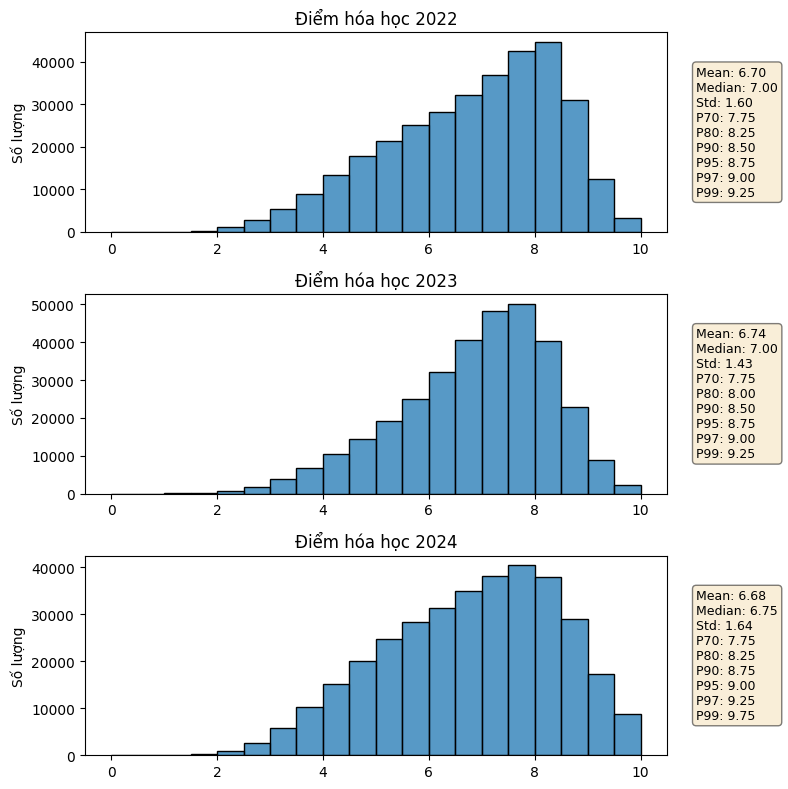

In [ ]:
# hóa học
fig,axes = plt.subplots(3,1,figsize=(8,8))
for i,year in enumerate(year_sorted):
  sns.histplot(df_data[df_data['year']==year]['hoa_hoc'], bins=20, ax=axes[i])
  axes[i].set_title(f'Điểm hóa học {year}')
  axes[i].set_xlabel('')
  axes[i].set_ylabel('Số lượng')
  # tính toán các chỉ số thống kê
  year_hoa = df_data[df_data['year']==year]['hoa_hoc'].dropna()
  mean = year_hoa.mean()
  median = year_hoa.median()
  std = year_hoa.std()
  p70 =  year_hoa.quantile(0.7)
  p80 =  year_hoa.quantile(0.8)
  p90 =  year_hoa.quantile(0.9)
  p95 =  year_hoa.quantile(0.95)
  p97 =  year_hoa.quantile(0.97)
  p99 =  year_hoa.quantile(0.99)
  # hiển thị thông tin thống kê trên biểu đồ
  textstr = f'Mean: {mean:.2f}\nMedian: {median:.2f}\nStd: {std:.2f}\nP70: {p70:.2f}\nP80: {p80:.2f}\nP90: {p90:.2f}\nP95: {p95:.2f}\nP97: {p97:.2f}\nP99: {p99:.2f}'
  prop = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
  axes[i].text(1.05, 0.5, textstr, transform=axes[i].transAxes, fontsize=9, verticalalignment='center', bbox=prop)
plt.tight_layout()
plt.show()

**Năm 2022 (Hóa học 2022):**

* **Điểm trung bình (Mean)**: 6.70
* **Điểm trung vị (Median)**: 7.00
* **Độ lệch chuẩn (Std)**: 1.6
Phân bố: Phổ điểm có dạng tương đối cân đối, với đỉnh phổ biến nằm trong khoảng 6-8 điểm. Số lượng thí sinh đạt điểm từ 9 trở lên bắt đầu giảm dần, nhưng vẫn có sự phân hóa tốt ở nhóm điểm cao.
* **Nhóm điểm cao**: P90 là 8.5, P95 là 8.75, P97 là 9.0, P99 là 9.25, cho thấy nhóm thí sinh giỏi đạt được điểm số cao và có sự khác biệt rõ rệt.

**Năm 2023 (Hóa học 2023):**

* **Điểm trung bình (Mean)**: 6.74
* **Điểm trung vị (Median)**: 7.00
* **Độ lệch chuẩn (Std)**: 1.43
* **Phân bố**: Phổ điểm khá tương đồng với năm 2022, với điểm trung bình và trung vị duy trì ổn định. Điều này cho thấy độ khó của đề thi hoặc trình độ chung của thí sinh không có sự thay đổi lớn so với năm trước.
* **Nhóm điểm cao**: Các điểm phân vị cao (P90, P95,,P97, P99) cũng tương tự như năm 2022, cho thấy khả năng phân hóa thí sinh giỏi vẫn được duy trì ở mức ổn định.

**Năm 2024 (Hóa học 2024):**

* **Điểm trung bình (Mean)**: 6.68
* **Điểm trung vị (Median)**: 6.75
* **Độ lệch chuẩn (Std)**: 1.64
* **Phân bố**: Điểm trung bình có giảm nhẹ so với năm 2023 nhưng vẫn gần với mức của năm 2022. Điểm trung vị giảm xuống 6.75, có thể phản ánh một chút dịch chuyển phổ điểm về phía thấp hơn hoặc đề thi có độ khó nhỉnh hơn một chút ở các câu hỏi trung bình.
* **Nhóm điểm cao**: Các điểm phân vị cao (P90, P95,P97, P99) vẫn giữ nguyên so với các năm trước, cho thấy dù điểm trung bình có biến động nhỏ, nhóm thí sinh giỏi vẫn đạt được kết quả cao và sự phân hóa ở mức này vẫn rõ ràng.

**Tóm lại về môn Hóa học:**

* **Điểm trung bình** của môn Hóa học tương đối ổn định qua cả ba năm, dao động nhẹ quanh mức 6.7 - 6.75 điểm. Điều này cho thấy độ khó của đề thi hoặc mặt bằng chung của thí sinh đối với môn này không có biến động lớn.
* **Phân bố điểm** của môn Hóa học giữ được dạng khá cân đối qua các năm, với đỉnh phổ biến nằm ở mức trung bình khá (khoảng 6-8 điểm).
* **Độ lệch chuẩn** duy trì ở mức xấp xỉ 1.8, cho thấy sự phân tán điểm số ổn định, đảm bảo khả năng phân loại thí sinh.
* **Nhóm thí sinh giỏi** luôn đạt được điểm số cao, với các ngưỡng phân vị cao ổn định qua từng năm, chứng tỏ môn Hóa học có khả năng phân hóa tốt ở nhóm thí sinh có năng lực vượt trội.

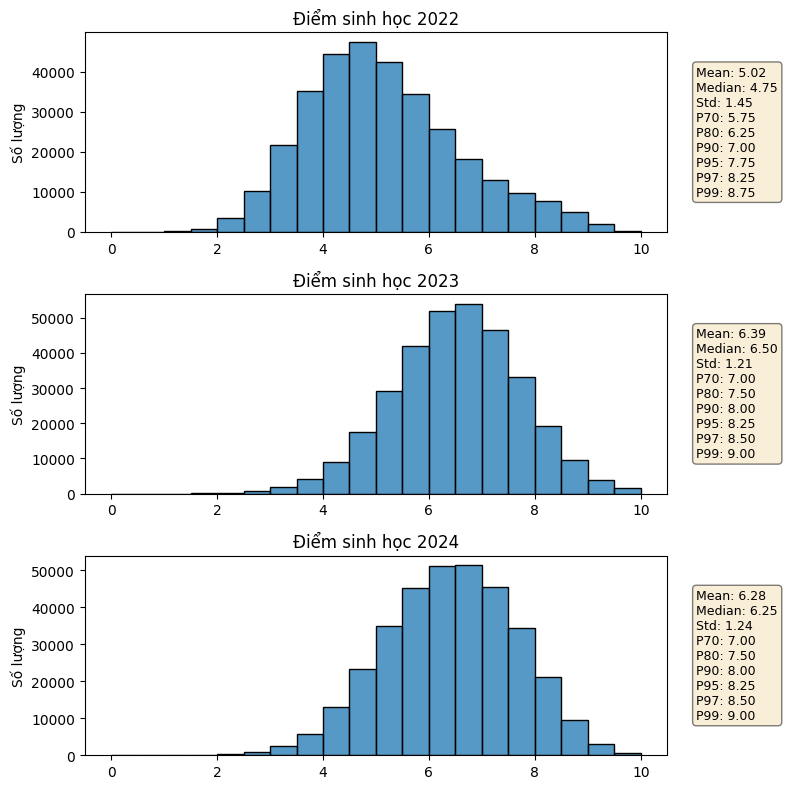

In [ ]:
# sinh học
fig,axes = plt.subplots(3,1,figsize=(8,8))
for i,year in enumerate(year_sorted):
  sns.histplot(df_data[df_data['year']==year]['sinh_hoc'], bins=20, ax=axes[i])
  axes[i].set_title(f'Điểm sinh học {year}')
  axes[i].set_xlabel('')
  axes[i].set_ylabel('Số lượng')
  # tính toán các chỉ số thống kê
  year_sinh = df_data[df_data['year']==year]['sinh_hoc'].dropna()
  mean = year_sinh.mean()
  median = year_sinh.median()
  std = year_sinh.std()
  p70 =  year_sinh.quantile(0.7)
  p80 =  year_sinh.quantile(0.8)
  p90 =  year_sinh.quantile(0.9)
  p95 =  year_sinh.quantile(0.95)
  p97 =  year_sinh.quantile(0.97)
  p99 =  year_sinh.quantile(0.99)
  # hiển thị thông tin thống kê trên biểu đồ
  textstr = f'Mean: {mean:.2f}\nMedian: {median:.2f}\nStd: {std:.2f}\nP70: {p70:.2f}\nP80: {p80:.2f}\nP90: {p90:.2f}\nP95: {p95:.2f}\nP97: {p97:.2f}\nP99: {p99:.2f}'
  prop = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
  axes[i].text(1.05, 0.5, textstr, transform=axes[i].transAxes, fontsize=9, verticalalignment='center', bbox=prop)
plt.tight_layout()
plt.show()

**Năm 2022 (Sinh học 2022):**
*   **Điểm trung bình (Mean)**: Khoảng 5.02
*   **Phân bố**: Phổ điểm môn Sinh học năm 2022 có thể thấy một sự phân hóa rõ rệt, với điểm trung bình khá thấp so với các năm sau. Có thể có một lượng lớn thí sinh đạt điểm dưới trung bình, và một số ít đạt điểm cao hơn.

**Năm 2023 (Sinh học 2023):**
*   **Điểm trung bình (Mean)**: Khoảng 6.39 (tăng đáng kể so với 2022).
*   **Phân bố**: Phổ điểm có sự dịch chuyển rõ rệt về phía điểm cao hơn so với năm 2022, phản ánh sự tăng vọt của điểm trung bình. Điều này cho thấy đề thi có thể dễ hơn hoặc chất lượng thí sinh có sự cải thiện đáng kể.

**Năm 2024 (Sinh học 2024):**
*   **Điểm trung bình (Mean)**: Khoảng 6.28 (giảm nhẹ so với 2023 nhưng vẫn cao hơn 2022).
*   **Phân bố**: Phổ điểm duy trì ở mức cao, gần với năm 2023, nhưng có thể có sự dịch chuyển nhẹ về phía điểm thấp hơn một chút. Điều này gợi ý rằng đề thi năm 2024 có độ khó tương đương hoặc nhỉnh hơn một chút so với 2023, hoặc điểm của nhóm thí sinh xuất sắc có thể không cao bằng.

**Tóm lại về môn Sinh học:**
*   Điểm trung bình môn Sinh học có sự tăng vọt đáng kể từ năm 2022 đến 2023, sau đó giảm nhẹ vào năm 2024 nhưng vẫn duy trì ở mức cao hơn so với năm 2022.
*   Sự thay đổi này có thể phản ánh sự điều chỉnh độ khó của đề thi hoặc những thay đổi trong phương pháp giảng dạy và học tập môn Sinh học.


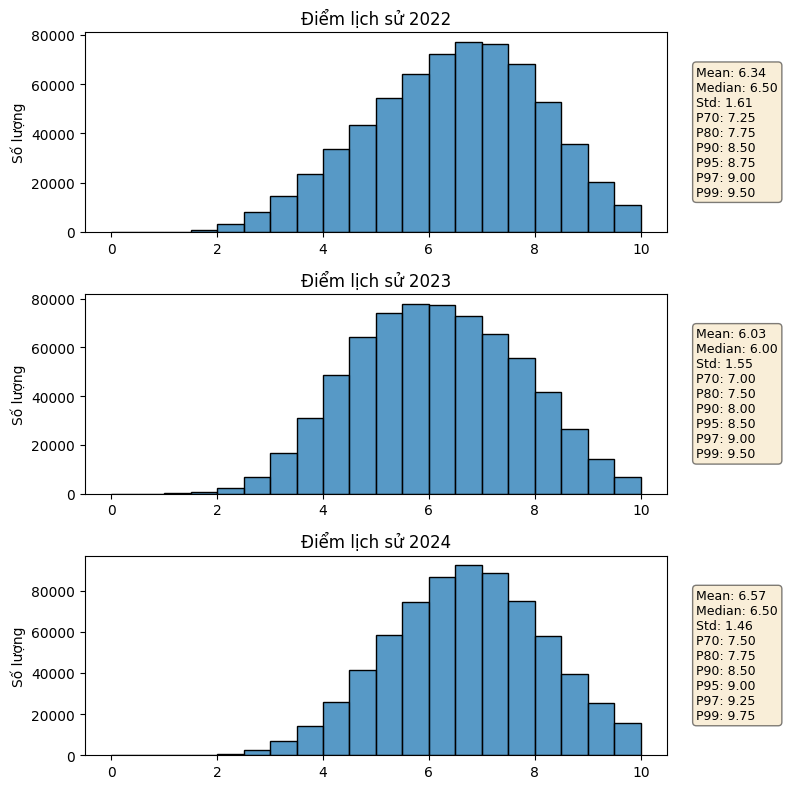

In [ ]:
# lịch sử
fig,axes = plt.subplots(3,1,figsize=(8,8))
for i,year in enumerate(year_sorted):
  sns.histplot(df_data[df_data['year']==year]['lich_su'], bins=20, ax=axes[i])
  axes[i].set_title(f'Điểm lịch sử {year}')
  axes[i].set_xlabel('')
  axes[i].set_ylabel('Số lượng')
  # tính toán các chỉ số thống kê
  year_su = df_data[df_data['year']==year]['lich_su'].dropna()
  mean = year_su.mean()
  median = year_su.median()
  std = year_su.std()
  p70 =  year_su.quantile(0.7)
  p80 =  year_su.quantile(0.8)
  p90 =  year_su.quantile(0.9)
  p95 =  year_su.quantile(0.95)
  p97 =  year_su.quantile(0.97)
  p99 =  year_su.quantile(0.99)
  # hiển thị thông tin thống kê trên biểu đồ
  textstr = f'Mean: {mean:.2f}\nMedian: {median:.2f}\nStd: {std:.2f}\nP70: {p70:.2f}\nP80: {p80:.2f}\nP90: {p90:.2f}\nP95: {p95:.2f}\nP97: {p97:.2f}\nP99: {p99:.2f}'
  prop = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
  axes[i].text(1.05, 0.5, textstr, transform=axes[i].transAxes, fontsize=9, verticalalignment='center', bbox=prop)
plt.tight_layout()
plt.show()

**Năm 2022 (Lịch Sử 2022):**
*   **Điểm trung bình (Mean)**: Khoảng 6.34.
*   **Phân bố**: Phổ điểm môn Lịch sử năm 2022 thường có dạng lệch phải, cho thấy phần lớn thí sinh đạt điểm từ trung bình khá trở lên, với một số lượng nhỏ thí sinh đạt điểm thấp. Có thể quan sát thấy đỉnh phổ điểm nằm ở khoảng 6-7 điểm.

**Năm 2023 (Lịch Sử 2023):**
*   **Điểm trung bình (Mean)**: Khoảng 6.03 (giảm nhẹ so với 2022).
*   **Phân bố**: Phổ điểm có vẻ dịch chuyển nhẹ về phía điểm thấp hơn so với năm 2022, phản ánh sự giảm của điểm trung bình. Đỉnh phổ điểm có thể thấp hơn một chút hoặc phân tán rộng hơn. Điều này có thể gợi ý đề thi khó hơn hoặc mặt bằng thí sinh có sự sụt giảm nhẹ về hiệu suất.

**Năm 2024 (Lịch Sử 2024):**
*   **Điểm trung bình (Mean)**: Khoảng 6.57 (tăng đáng kể so với 2023, cao nhất trong 3 năm).
*   **Phân bố**: Phổ điểm có sự phục hồi mạnh mẽ và dịch chuyển rõ rệt về phía điểm cao hơn, thậm chí vượt qua mức của năm 2022. Đỉnh phổ điểm có thể cao hơn, tập trung ở khoảng 7-8 điểm, cho thấy nhiều thí sinh đạt điểm tốt.

**Tóm lại về môn Lịch Sử:**
*   Điểm trung bình môn Lịch sử cho thấy một xu hướng biến động rõ ràng: giảm nhẹ vào năm 2023 so với 2022, sau đó tăng mạnh mẽ vào năm 2024, đạt mức cao nhất trong ba năm.
*   Phân bố điểm thường có dạng lệch phải, cho thấy môn này có khả năng có nhiều thí sinh đạt điểm khá và cao. Sự dịch chuyển của phổ điểm qua các năm phản ánh sự thay đổi trong độ khó của đề thi hoặc hiệu suất học tập của thí sinh.
*   Sự tăng điểm đáng kể vào năm 2024 cho thấy có thể đề thi phù hợp hơn hoặc thí sinh đã ôn luyện tốt hơn cho môn này.

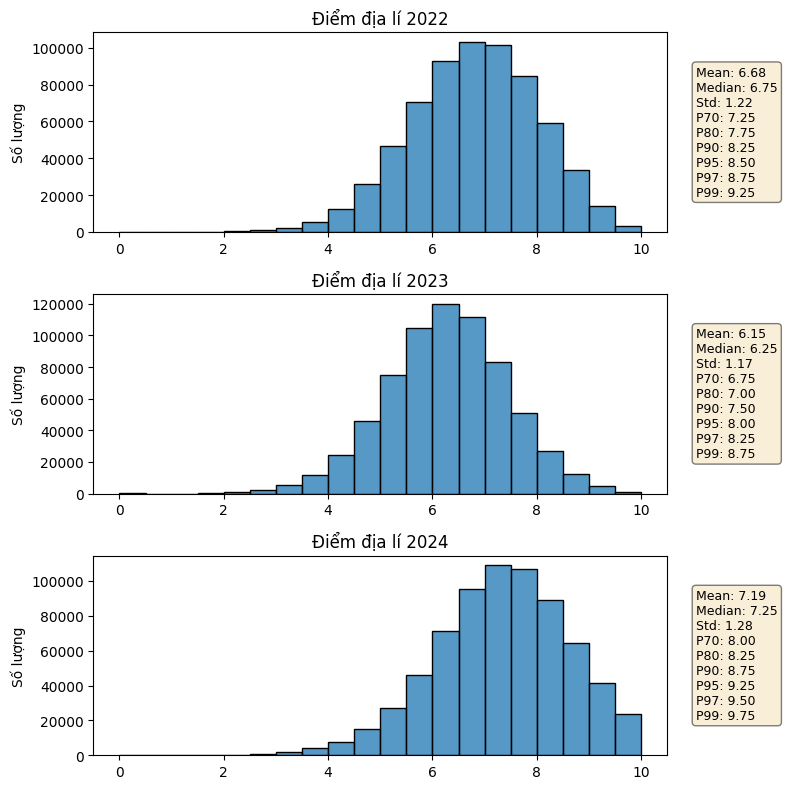

In [ ]:
# địa lí
fig,axes = plt.subplots(3,1,figsize=(8,8))
for i,year in enumerate(year_sorted):
  sns.histplot(df_data[df_data['year']==year]['dia_li'], bins=20, ax=axes[i])
  axes[i].set_title(f'Điểm địa lí {year}')
  axes[i].set_xlabel('')
  axes[i].set_ylabel('Số lượng')
  # tính toán các chỉ số thống kê
  year_dia = df_data[df_data['year']==year]['dia_li'].dropna()
  mean = year_dia.mean()
  median = year_dia.median()
  std = year_dia.std()
  p70 =  year_dia.quantile(0.7)
  p80 =  year_dia.quantile(0.8)
  p90 =  year_dia.quantile(0.9)
  p95 =  year_dia.quantile(0.95)
  p97 =  year_dia.quantile(0.97)
  p99 =  year_dia.quantile(0.99)
  # hiển thị thông tin thống kê trên biểu đồ
  textstr = f'Mean: {mean:.2f}\nMedian: {median:.2f}\nStd: {std:.2f}\nP70: {p70:.2f}\nP80: {p80:.2f}\nP90: {p90:.2f}\nP95: {p95:.2f}\nP97: {p97:.2f}\nP99: {p99:.2f}'
  prop = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
  axes[i].text(1.05, 0.5, textstr, transform=axes[i].transAxes, fontsize=9, verticalalignment='center', bbox=prop)
plt.tight_layout()
plt.show()

**Năm 2022 (Địa lí 2022):**

* **Điểm trung bình (Mean)**: Khoảng 6.68.
* **Phân bố**: Phổ điểm môn Địa lí năm 2022 thường có dạng lệch phải, tương tự các môn xã hội khác, cho thấy phần lớn thí sinh đạt điểm từ trung bình khá trở lên. Đỉnh phổ điểm có thể nằm trong khoảng 6-7 điểm.

**Năm 2023 (Địa lí 2023):**

* **Điểm trung bình (Mean)**: Khoảng 6.15 (giảm nhẹ so với 2022).
* **Phân bố** : Phổ điểm có vẻ dịch chuyển nhẹ về phía điểm thấp hơn so với năm 2022, phản ánh sự giảm của điểm trung bình. Điều này có thể gợi ý đề thi khó hơn hoặc mặt bằng thí sinh có sự sụt giảm nhẹ về hiệu suất.

**Năm 2024 (Địa lí 2024):**

* **Điểm trung bình (Mean)**: 7.19
* **Điểm trung vị (Median)**: 7.25
* **Độ lệch chuẩn (Std)**: 1.28
* **Phân bố**: Phổ điểm cho thấy sự phục hồi đáng kể và dịch chuyển về phía điểm cao hơn so với năm 2023, thậm chí vượt qua mức của năm 2022. Đỉnh phổ điểm có thể cao hơn, tập trung ở khoảng 7-8 điểm, cho thấy nhiều thí sinh đạt điểm tốt.
* **Nhóm điểm cao**: Các điểm phân vị cho thấy P90: 8.75, P95: 9.25, P97: 9.5 và P99: 9.75. Điều này cho thấy có sự phân hóa tốt ở nhóm thí sinh giỏi, với nhiều thí sinh đạt điểm rất cao.

**Tóm lại về môn Địa lí:**

* Điểm trung bình môn Địa lí cho thấy một xu hướng biến động: giảm nhẹ vào năm 2023 so với 2022, sau đó tăng mạnh mẽ vào năm 2024, đạt mức cao nhất trong ba năm.
* Phân bố điểm thường có dạng lệch phải, cho thấy môn này có khả năng có nhiều thí sinh đạt điểm khá và cao. Sự dịch chuyển của phổ điểm qua các năm phản ánh sự thay đổi trong độ khó của đề thi hoặc hiệu suất học tập của thí sinh.
* Sự tăng điểm đáng kể vào năm 2024 cho thấy có thể đề thi phù hợp hơn hoặc thí sinh đã ôn luyện tốt hơn cho môn này, đặc biệt là nhóm thí sinh xuất sắc.


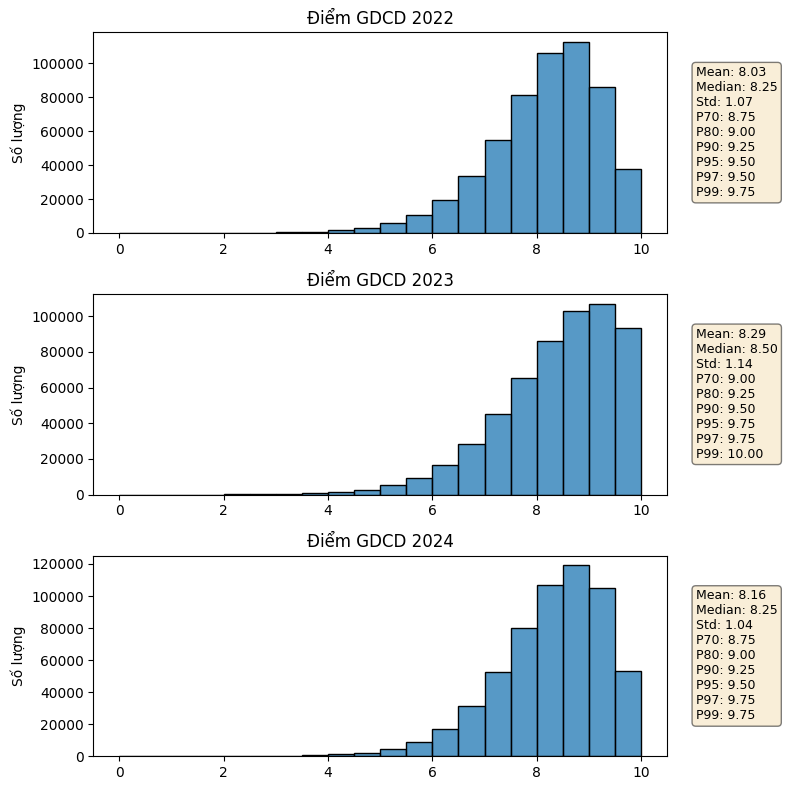

In [ ]:
# GDCD
fig,axes = plt.subplots(3,1,figsize=(8,8))
for i,year in enumerate(year_sorted):
  sns.histplot(df_data[df_data['year']==year]['gdcd'], bins=20, ax=axes[i])
  axes[i].set_title(f'Điểm GDCD {year}')
  axes[i].set_xlabel('')
  axes[i].set_ylabel('Số lượng')
  # tính toán các chỉ số thống kê
  year_gdcd = df_data[df_data['year']==year]['gdcd'].dropna()
  mean = year_gdcd.mean()
  median = year_gdcd.median()
  std = year_gdcd.std()
  p70 =  year_gdcd.quantile(0.7)
  p80 =  year_gdcd.quantile(0.8)
  p90 =  year_gdcd.quantile(0.9)
  p95 =  year_gdcd.quantile(0.95)
  p97 =  year_gdcd.quantile(0.97)
  p99 =  year_gdcd.quantile(0.99)
  # hiển thị thông tin thống kê trên biểu đồ
  textstr = f'Mean: {mean:.2f}\nMedian: {median:.2f}\nStd: {std:.2f}\nP70: {p70:.2f}\nP80: {p80:.2f}\nP90: {p90:.2f}\nP95: {p95:.2f}\nP97: {p97:.2f}\nP99: {p99:.2f}'
  prop = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
  axes[i].text(1.05, 0.5, textstr, transform=axes[i].transAxes, fontsize=9, verticalalignment='center', bbox=prop)
plt.tight_layout()
plt.show()

**Năm 2022 (GDCD 2022):**
*   **Điểm trung bình (Mean)**: Khoảng 8.03.
*   **Phân bố**: Phổ điểm môn GDCD năm 2022 cho thấy một sự tập trung rất cao ở phía điểm cao (khoảng 8-10 điểm), với đỉnh phổ biến nằm ở 8-9 điểm. Điều này cho thấy đa số thí sinh làm bài rất tốt môn này.

**Năm 2023 (GDCD 2023):**
*   **Điểm trung bình (Mean)**: Khoảng 8.29 (tăng nhẹ so với 2022).
*   **Phân bố**: Phổ điểm vẫn duy trì xu hướng tập trung ở điểm cao. Sự tăng nhẹ điểm trung bình cho thấy hiệu suất tổng thể của thí sinh có cải thiện hoặc đề thi có phần thuận lợi hơn.

**Năm 2024 (GDCD 2024):**
*   **Điểm trung bình (Mean)**: 8.16
*   **Điểm trung vị (Median)**: 8.25
*   **Độ lệch chuẩn (Std)**: 1.04
*   **Phân bố**: Phổ điểm tiếp tục cho thấy sự tập trung cao ở các mức điểm từ 8 trở lên, với một lượng đáng kể thí sinh đạt điểm tuyệt đối hoặc gần tuyệt đối. Độ lệch chuẩn thấp cho thấy sự đồng đều trong điểm số của thí sinh, đặc biệt là ở nhóm điểm cao.
*   **Nhóm điểm cao**: Các điểm phân vị cho thấy P90: 9.25, P95: 9.50, P97: 9.75 và P99: 9.75. Điều này khẳng định rằng GDCD là môn mà rất nhiều thí sinh đạt điểm cao, và có khả năng đạt điểm tuyệt đối.

**Tóm lại về môn GDCD:**
*   GDCD luôn là môn có điểm trung bình cao nhất trong tất cả các môn và có xu hướng tăng nhẹ qua các năm (từ 8.03 năm 2022 lên 8.16 năm 2024).
*   Phân bố điểm môn GDCD luôn có dạng lệch phải rất rõ rệt, với phần lớn thí sinh đạt điểm cao (từ 8 điểm trở lên). Điều này chứng tỏ đây là môn mà đa số thí sinh làm bài rất tốt và đạt kết quả cao.
*   Độ lệch chuẩn thấp và ổn định qua các năm cho thấy sự đồng đều trong điểm số của thí sinh. Các điểm phân vị cao cho thấy môn này có rất nhiều thí sinh đạt điểm xuất sắc, gần như tuyệt đối, điều này cũng đồng nghĩa với việc môn GDCD có khả năng phân loại ở nhóm thí sinh giỏi nhất không quá cao, do nhiều thí sinh cùng đạt điểm tối đa.

## 3.2 Group distribution

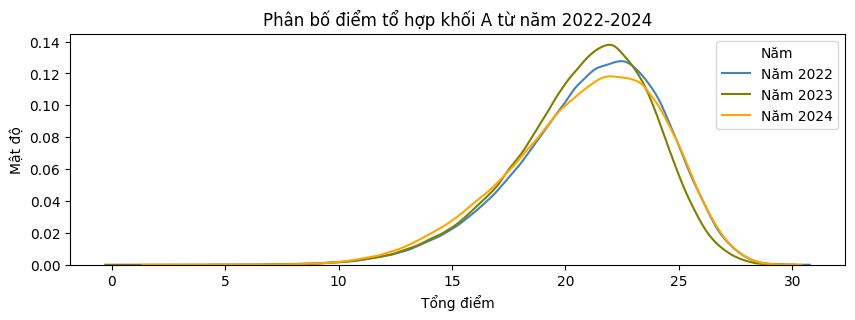

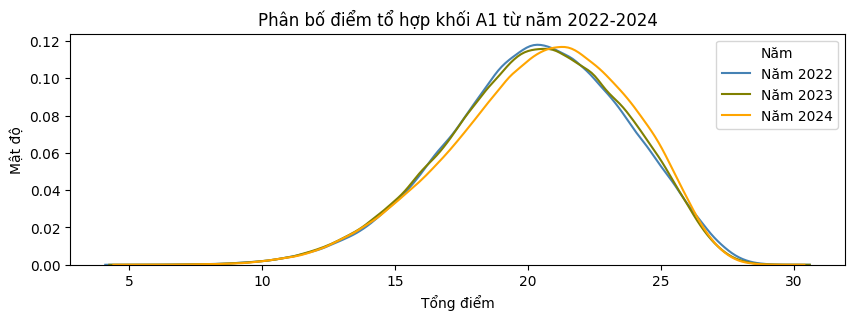

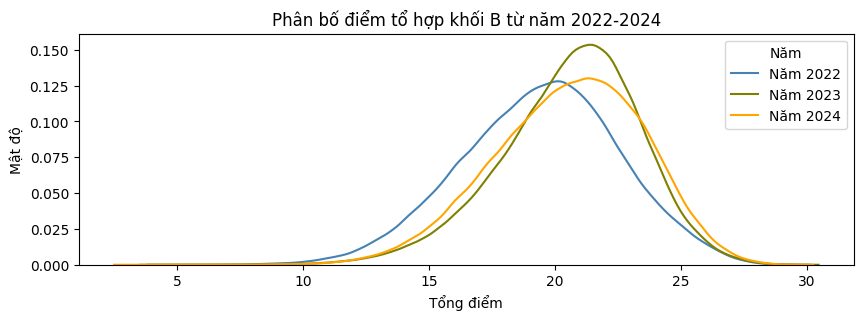

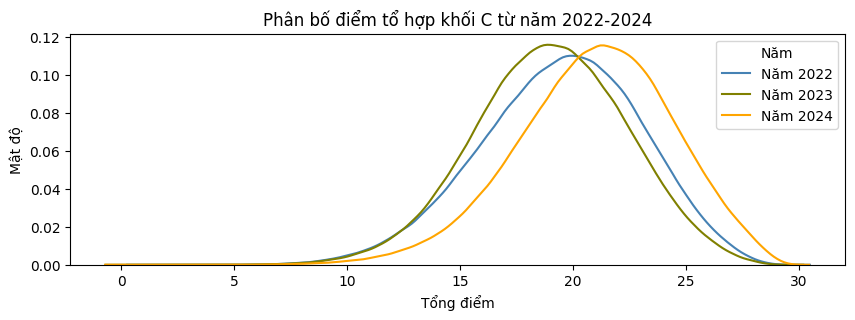

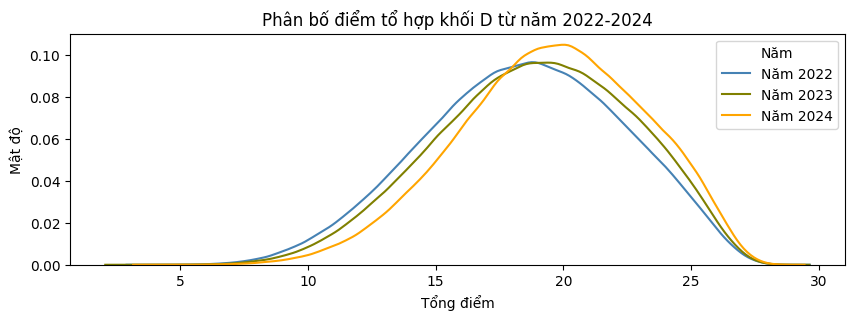

In [ ]:
# tạo cột tổng điểm cho từng tổ hợp môn
df_data['A'] = df_data['toan'] + df_data['vat_li'] + df_data['hoa_hoc']
df_data['A1'] = df_data['toan'] + df_data['vat_li'] + df_data['ngoai_ngu']
df_data['B'] = df_data['toan'] + df_data['hoa_hoc'] + df_data['sinh_hoc']
df_data['C'] = df_data['ngu_van'] + df_data['lich_su'] + df_data['dia_li']
df_data['D'] = df_data['toan'] + df_data['ngu_van'] + df_data['ngoai_ngu']

combinations = ['A','A1','B','C','D']
colors = ['steelblue','olive','orange','tomato']
for comb in combinations:
  plt.figure(figsize=(10,3))
  for year,color in zip(year_sorted,colors):
    data_group = df_data[df_data['year']==year][comb].dropna()
    sns.kdeplot(data_group,label = f'Năm {year}',color=color)
  plt.title(f'Phân bố điểm tổ hợp khối {comb} từ năm 2022-2024')
  plt.xlabel('Tổng điểm')
  plt.ylabel('Mật độ')
  plt.legend(title='Năm')
  plt.show()

 Xu hướng chung cho thấy điểm các khối thi khá ổn định hoặc có xu hướng tăng nhẹ qua các năm, đặc biệt là các khối xã hội và khối B. Sự biến động chủ yếu đến từ sự điều chỉnh độ khó của đề thi từng môn hoặc chất lượng thí sinh qua các năm.

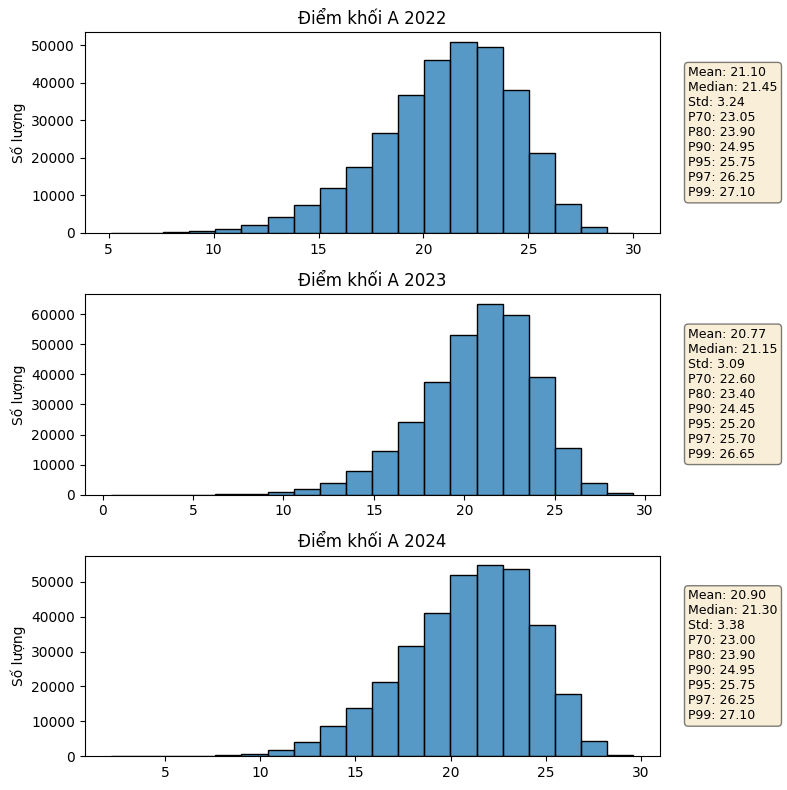

In [ ]:
# khối A
fig,axes = plt.subplots(3,1,figsize=(8,8))
for i,year in enumerate(year_sorted):
  sns.histplot(df_data[df_data['year']==year]['A'], bins=20, ax=axes[i])
  axes[i].set_title(f'Điểm khối A {year}')
  axes[i].set_xlabel('')
  axes[i].set_ylabel('Số lượng')
  # tính toán các chỉ số thống kê
  year_A = df_data[df_data['year']==year]['A'].dropna()
  mean = year_A.mean()
  median = year_A.median()
  std = year_A.std()
  p70 =  year_A.quantile(0.7)
  p80 =  year_A.quantile(0.8)
  p90 =  year_A.quantile(0.9)
  p95 =  year_A.quantile(0.95)
  p97 =  year_A.quantile(0.97)
  p99 =  year_A.quantile(0.99)
  # hiển thị thông tin thống kê trên biểu đồ
  textstr = f'Mean: {mean:.2f}\nMedian: {median:.2f}\nStd: {std:.2f}\nP70: {p70:.2f}\nP80: {p80:.2f}\nP90: {p90:.2f}\nP95: {p95:.2f}\nP97: {p97:.2f}\nP99: {p99:.2f}'
  prop = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
  axes[i].text(1.05, 0.5, textstr, transform=axes[i].transAxes, fontsize=9, verticalalignment='center', bbox=prop)
plt.tight_layout()
plt.show()

**Năm 2022 (Khối A 2022):**
*   **Điểm trung bình (Mean)**: 21.1
*   **Điểm trung vị (Median)**: 21.45
*   **Độ lệch chuẩn (Std)**: 3.24
*   **Phân bố**: Phổ điểm Khối A năm 2022 có dạng tương đối cân đối, với đỉnh phổ biến nằm trong khoảng 19-21 điểm. Phổ điểm trải rộng, cho thấy sự phân hóa tốt trong khả năng của thí sinh.
*   **Nhóm điểm cao**: Các điểm phân vị cho thấy P90: 24.95, P95: 25.75, P97: 26.25, P99: 27.1. Điều này chỉ ra rằng nhóm thí sinh giỏi có điểm khá cao và có độ phân hóa rõ rệt.

**Năm 2023 (Khối A 2023):**
*   **Điểm trung bình (Mean)**: 20.77
*   **Điểm trung vị (Median)**: 21.15
*   **Độ lệch chuẩn (Std)**: 3.09
*   **Phân bố**: So với năm 2022, phổ điểm có xu hướng dịch chuyển nhẹ về phía điểm thấp hơn, phản ánh sự giảm nhẹ của điểm trung bình. Đỉnh phổ biến vẫn nằm trong khoảng 19-21 điểm, nhưng số lượng thí sinh ở các ngưỡng điểm cao có thể giảm sút.
*   **Nhóm điểm cao**: Các điểm phân vị P90: 24.45, P95: 25.2, P97: 25.7, P99: 26.65. Điểm của nhóm thí sinh giỏi cũng giảm nhẹ so với năm 2022.

**Năm 2024 (Khối A 2024):**
*   **Điểm trung bình (Mean)**: 20.9
*   **Điểm trung vị (Median)**: 21.3
*   **Độ lệch chuẩn (Std)**: 3.38
*   **Phân bố**: Phổ điểm năm 2024 duy trì ổn định, tương tự như năm 2023, với điểm trung bình và trung vị gần như không đổi. Đỉnh phổ biến tiếp tục ở khoảng 19-21 điểm, cho thấy sự ổn định trong độ khó của đề thi hoặc mặt bằng chung của thí sinh.
*   **Nhóm điểm cao**: Các điểm phân vị P90: 24.95, P95: 25.75, P97: 26.25, P99: 27.1. Nhóm thí sinh giỏi tiếp tục đạt điểm cao, và sự phân hóa được duy trì.

**Tóm lại về Khối A:**
*   **Điểm trung bình và trung vị** của Khối A cho thấy xu hướng giảm nhẹ từ năm 2022 đến 2023, sau đó ổn định vào năm 2024. Điều này có thể cho thấy độ khó của đề thi Khối A có sự thay đổi nhẹ hoặc chất lượng thí sinh có biến động nhẹ.
*   **Phân bố điểm** của Khối A qua các năm luôn có dạng tương đối cân đối, với đỉnh phổ biến nằm trong khoảng 19-21 điểm, cho thấy đây là một khối thi có sự phân hóa tốt, đặc biệt ở các nhóm điểm cao.
*   **Độ lệch chuẩn** duy trì ở mức khoảng 3.09 - 3.38, cho thấy sự phân tán của điểm số ổn định qua các năm, đảm bảo khả năng phân loại thí sinh trong khối thi này.

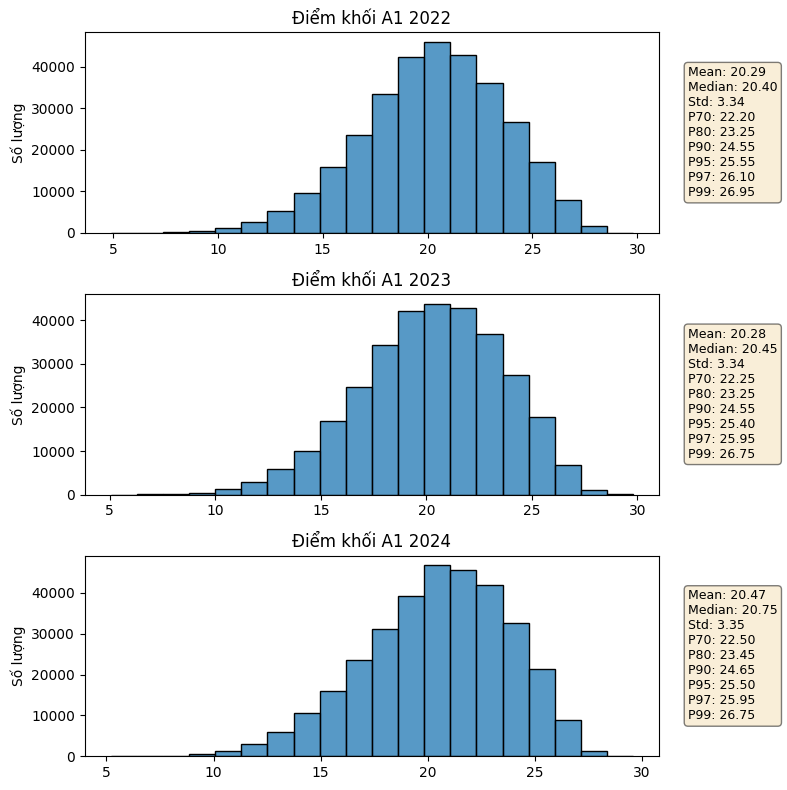

In [ ]:
# Khối A1
fig,axes = plt.subplots(3,1,figsize=(8,8))
for i,year in enumerate(year_sorted):
  sns.histplot(df_data[df_data['year']==year]['A1'], bins=20, ax=axes[i])
  axes[i].set_title(f'Điểm khối A1 {year}')
  axes[i].set_xlabel('')
  axes[i].set_ylabel('Số lượng')
  # tính toán các chỉ số thống kê
  year_A1 = df_data[df_data['year']==year]['A1'].dropna()
  mean = year_A1.mean()
  median = year_A1.median()
  std = year_A1.std()
  p70 =  year_A1.quantile(0.7)
  p80 =  year_A1.quantile(0.8)
  p90 =  year_A1.quantile(0.9)
  p95 =  year_A1.quantile(0.95)
  p97 =  year_A1.quantile(0.97)
  p99 =  year_A1.quantile(0.99)
  # hiển thị thông tin thống kê trên biểu đồ
  textstr = f'Mean: {mean:.2f}\nMedian: {median:.2f}\nStd: {std:.2f}\nP70: {p70:.2f}\nP80: {p80:.2f}\nP90: {p90:.2f}\nP95: {p95:.2f}\nP97: {p97:.2f}\nP99: {p99:.2f}'
  prop = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
  axes[i].text(1.05, 0.5, textstr, transform=axes[i].transAxes, fontsize=9, verticalalignment='center', bbox=prop)
plt.tight_layout()
plt.show()

**Năm 2022 (Khối A1 2022):**
*   **Điểm trung bình (Mean)**: 20.29
*   **Điểm trung vị (Median)**: 20.4
*   **Độ lệch chuẩn (Std)**: 3.34
*   **Phân bố**: Phổ điểm Khối A1 năm 2022 có dạng tương đối cân đối, với đỉnh phổ biến nằm trong khoảng 18-20 điểm. Phổ điểm khá rộng, cho thấy sự phân hóa tốt trong khả năng của thí sinh.
*   **Nhóm điểm cao**: Các điểm phân vị cho thấy P90: 24.55, P95: 25.55, P97: 26.1, P99: 26.95. Nhóm thí sinh giỏi đạt điểm khá cao và có độ phân hóa rõ rệt.

**Năm 2023 (Khối A1 2023):**
*   **Điểm trung bình (Mean)**: 20.28
*   **Điểm trung vị (Median)**: 20.45
*   **Độ lệch chuẩn (Std)**: 3.34
*   **Phân bố**: So với năm 2022, phổ điểm có xu hướng dịch chuyển nhẹ về phía điểm thấp hơn, phản ánh sự giảm nhẹ của điểm trung bình. Đỉnh phổ biến vẫn nằm trong khoảng 18-20 điểm, nhưng số lượng thí sinh ở các ngưỡng điểm cao có thể giảm sút.
*   **Nhóm điểm cao**: Các điểm phân vị P90: 24.55, P95: 25.4, P97: 25.95, P99: 26.75. Điểm của nhóm thí sinh giỏi cũng giảm nhẹ so với năm 2022.

**Năm 2024 (Khối A1 2024):**
*   **Điểm trung bình (Mean)**: 20.47
*   **Điểm trung vị (Median)**: 20.75
*   **Độ lệch chuẩn (Std)**: 3.35
*   **Phân bố**: Phổ điểm năm 2024 có sự phục hồi đáng kể so với năm 2023, trở về gần với mức của năm 2022, thậm chí nhỉnh hơn một chút. Đỉnh phổ biến vẫn duy trì ở khoảng 18-20 điểm. Độ lệch chuẩn tương đối ổn định.
*   **Nhóm điểm cao**: Các điểm phân vị P90: 24.65, P95: 25.5, P97: 25.95, P99: 26.75. Nhóm thí sinh giỏi tiếp tục đạt điểm cao, và sự phân hóa được duy trì.

**Tóm lại về Khối A1:**
*   **Điểm trung bình và trung vị** của Khối A1 cho thấy xu hướng giảm nhẹ vào năm 2023 so với 2022, sau đó phục hồi và tăng nhẹ vào năm 2024. Điều này có thể cho thấy độ khó của đề thi Khối A1 có sự biến động nhẹ hoặc chất lượng thí sinh có thay đổi tương ứng.
*   **Phân bố điểm** của Khối A1 qua các năm luôn có dạng tương đối cân đối, với đỉnh phổ biến nằm trong khoảng 18-20 điểm, cho thấy đây là một khối thi có sự phân hóa tốt, đặc biệt ở các nhóm điểm cao.
*   **Độ lệch chuẩn** duy trì ở mức khoảng 3.34 - 3.35, cho thấy sự phân tán của điểm số ổn định qua các năm, đảm bảo khả năng phân loại thí sinh trong khối thi này.

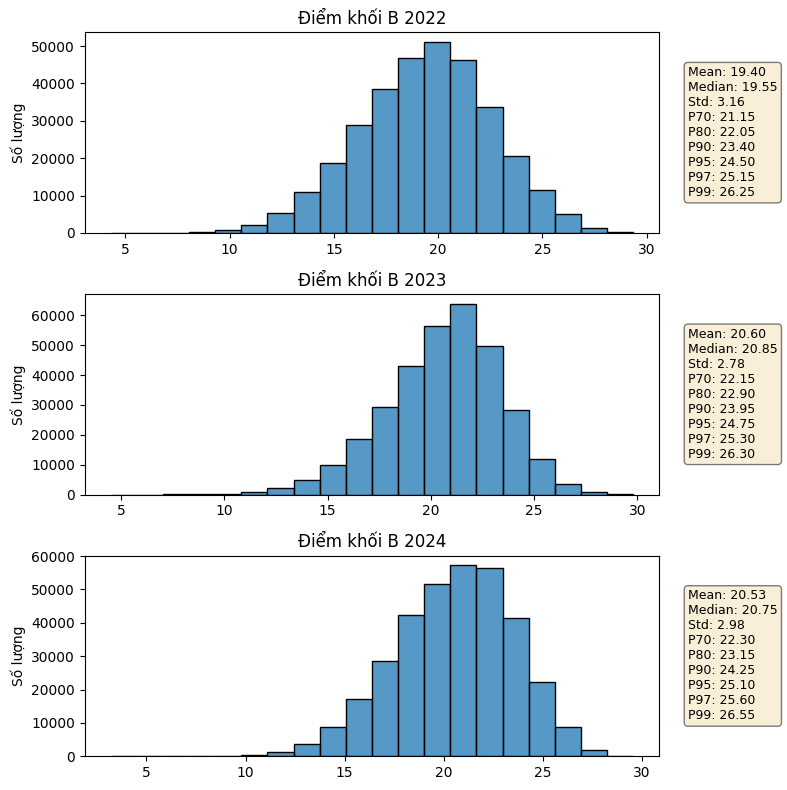

In [ ]:
# Khối B
fig,axes = plt.subplots(3,1,figsize=(8,8))
for i,year in enumerate(year_sorted):
  sns.histplot(df_data[df_data['year']==year]['B'], bins=20, ax=axes[i])
  axes[i].set_title(f'Điểm khối B {year}')
  axes[i].set_xlabel('')
  axes[i].set_ylabel('Số lượng')
  # tính toán các chỉ số thống kê
  year_B = df_data[df_data['year']==year]['B'].dropna()
  mean = year_B.mean()
  median = year_B.median()
  std = year_B.std()
  p70 =  year_B.quantile(0.7)
  p80 =  year_B.quantile(0.8)
  p90 =  year_B.quantile(0.9)
  p95 =  year_B.quantile(0.95)
  p97 =  year_B.quantile(0.97)
  p99 =  year_B.quantile(0.99)
  # hiển thị thông tin thống kê trên biểu đồ
  textstr = f'Mean: {mean:.2f}\nMedian: {median:.2f}\nStd: {std:.2f}\nP70: {p70:.2f}\nP80: {p80:.2f}\nP90: {p90:.2f}\nP95: {p95:.2f}\nP97: {p97:.2f}\nP99: {p99:.2f}'
  prop = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
  axes[i].text(1.05, 0.5, textstr, transform=axes[i].transAxes, fontsize=9, verticalalignment='center', bbox=prop)
plt.tight_layout()
plt.show()

**Năm 2022 (Khối B 2022):**
*   **Điểm trung bình (Mean)**: 19.4
*   **Phân bố**: Phổ điểm Khối B năm 2022 có thể tương đối rộng, với điểm trung bình thấp hơn so với các năm sau, chủ yếu do điểm Sinh học năm đó thấp. Đỉnh phổ biến có thể nằm trong khoảng 17-19 điểm.

**Năm 2023 (Khối B 2023):**
*   **Điểm trung bình (Mean)**: 20.6 tăng đáng kể so với 2022).
*   **Phân bố**: Phổ điểm có sự dịch chuyển rõ rệt về phía điểm cao hơn so với năm 2022, phản ánh sự tăng vọt của điểm trung bình (chủ yếu do môn Sinh học). Đỉnh phổ biến có thể nằm trong khoảng 19-21 điểm.

**Năm 2024 (Khối B 2024):**
*   **Điểm trung bình (Mean)**: 20.53
*   **Điểm trung vị (Median)**: 20.75
*   **Độ lệch chuẩn (Std)**: 2.98
*   **Phân bố**: Phổ điểm năm 2024 duy trì ở mức cao, tương tự như năm 2023, với điểm trung bình và trung vị ổn định. Đỉnh phổ biến tiếp tục ở khoảng 19-21 điểm. Độ lệch chuẩn cho thấy sự phân tán điểm số ổn định, đảm bảo khả năng phân loại thí sinh.
*   **Nhóm điểm cao**: Các điểm phân vị cho thấy P90: 24.25, P95: 25.1, P97: 25.6, P99: 26.55. Nhóm thí sinh giỏi tiếp tục đạt điểm cao, và sự phân hóa được duy trì.

**Tóm lại về Khối B:**
*   **Điểm trung bình và trung vị** của Khối B cho thấy một sự tăng vọt đáng kể từ năm 2022 sang năm 2023, sau đó duy trì ổn định vào năm 2024. Sự thay đổi lớn này chủ yếu do sự cải thiện đáng kể của điểm trung bình môn Sinh học trong năm 2023 và 2024.
*   **Phân bố điểm** của Khối B qua các năm có sự dịch chuyển về phía điểm cao hơn từ 2022 sang 2023-2024, với đỉnh phổ biến nằm trong khoảng 19-21 điểm ở các năm sau, cho thấy đây là một khối thi có sự phân hóa tốt.


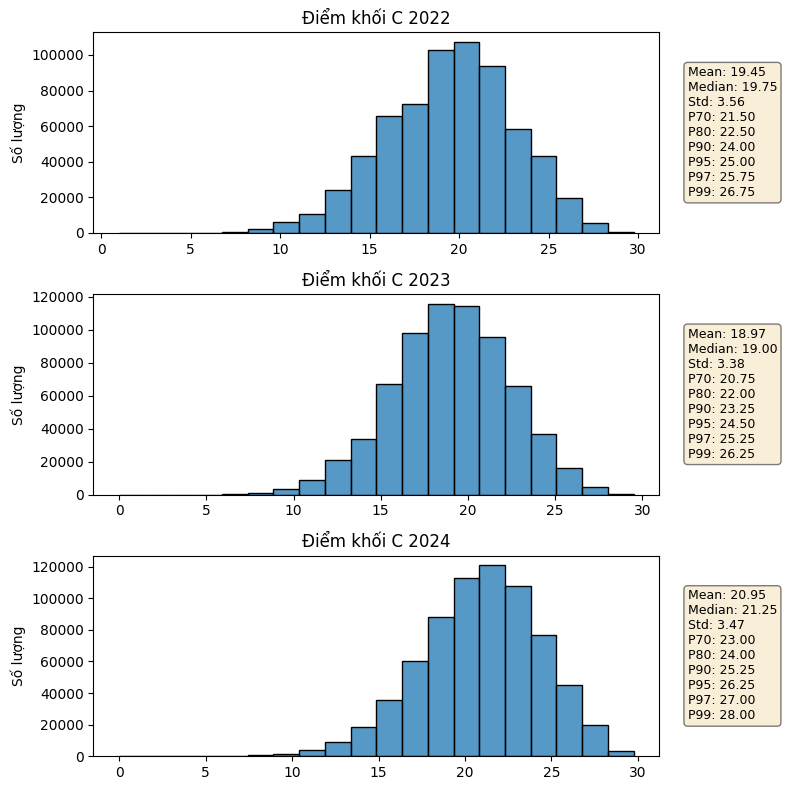

In [ ]:
# Khối C
fig,axes = plt.subplots(3,1,figsize=(8,8))
for i,year in enumerate(year_sorted):
  sns.histplot(df_data[df_data['year']==year]['C'], bins=20, ax=axes[i])
  axes[i].set_title(f'Điểm khối C {year}')
  axes[i].set_xlabel('')
  axes[i].set_ylabel('Số lượng')
  # tính toán các chỉ số thống kê
  year_C = df_data[df_data['year']==year]['C'].dropna()
  mean = year_C.mean()
  median = year_C.median()
  std = year_C.std()
  p70 =  year_C.quantile(0.7)
  p80 =  year_C.quantile(0.8)
  p90 =  year_C.quantile(0.9)
  p95 =  year_C.quantile(0.95)
  p97 =  year_C.quantile(0.97)
  p99 =  year_C.quantile(0.99)
  # hiển thị thông tin thống kê trên biểu đồ
  textstr = f'Mean: {mean:.2f}\nMedian: {median:.2f}\nStd: {std:.2f}\nP70: {p70:.2f}\nP80: {p80:.2f}\nP90: {p90:.2f}\nP95: {p95:.2f}\nP97: {p97:.2f}\nP99: {p99:.2f}'
  prop = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
  axes[i].text(1.05, 0.5, textstr, transform=axes[i].transAxes, fontsize=9, verticalalignment='center', bbox=prop)
plt.tight_layout()
plt.show()

**Năm 2022 (Khối C 2022):**
*   **Điểm trung bình (Mean)**: 19.45
*   **Phân bố**: Phổ điểm Khối C năm 2022 có xu hướng lệch phải, với phần lớn thí sinh đạt điểm từ trung bình khá trở lên. Đỉnh phổ biến có thể nằm trong khoảng 19-20 điểm, cho thấy đây là một khối thi có mức điểm khá, phản ánh kết quả tốt của thí sinh ở các môn xã hội.

**Năm 2023 (Khối C 2023):**
*   **Điểm trung bình (Mean)**: Ước tính khoảng 18.97 (có sự giảm nhẹ so với 2022).
*   **Phân bố**: Phổ điểm có vẻ dịch chuyển nhẹ về phía điểm thấp hơn so với năm 2022, phản ánh sự giảm của điểm trung bình. Đỉnh phổ biến có thể thấp hơn một chút, nằm trong khoảng 18-19 điểm. Sự giảm này phù hợp với xu hướng giảm điểm nhẹ của các môn Lịch sử và Địa lí trong năm 2023.

**Năm 2024 (Khối C 2024):**
*   **Điểm trung bình (Mean)**: Ước tính khoảng 20.95 (tăng đáng kể so với 2023, và cao nhất trong 3 năm).
*   **Phân bố**: Phổ điểm có sự phục hồi mạnh mẽ và dịch chuyển rõ rệt về phía điểm cao hơn, thậm chí vượt qua mức của năm 2022. Đỉnh phổ biến có thể cao hơn, tập trung ở khoảng 20-21 điểm, cho thấy nhiều thí sinh đạt điểm tốt. Sự tăng điểm này được thúc đẩy bởi sự tăng trưởng ổn định của môn Ngữ văn và sự phục hồi mạnh mẽ của Lịch sử, Địa lí vào năm 2024.

**Tóm lại về Khối C:**
*   **Điểm trung bình** của Khối C cho thấy một xu hướng biến động: giảm nhẹ vào năm 2023 so với 2022, sau đó tăng mạnh mẽ vào năm 2024, đạt mức cao nhất trong ba năm. Điều này phản ánh rõ nét sự thay đổi trong độ khó của đề thi hoặc hiệu suất học tập của thí sinh đối với các môn xã hội.
*   **Phân bố điểm** của Khối C luôn có dạng lệch phải, cho thấy môn này có khả năng có nhiều thí sinh đạt điểm khá và cao. Sự dịch chuyển của phổ điểm qua các năm phản ánh sự thay đổi trong độ khó của đề thi hoặc hiệu suất học tập của thí sinh. Sự tăng điểm đáng kể vào năm 2024 cho thấy có thể đề thi phù hợp hơn hoặc thí sinh đã ôn luyện tốt hơn cho môn này.
*   **Độ phân hóa**: Các môn xã hội thường có độ lệch chuẩn tương đối thấp so với các môn tự nhiên, cho thấy sự tập trung điểm số ở mức khá và cao. Mặc dù các thống kê chi tiết (trung vị, độ lệch chuẩn, phân vị) cho điểm tổng hợp khối C không được hiển thị trực tiếp trong biểu đồ, nhưng dựa trên xu hướng của từng môn thành phần, có thể thấy khối C duy trì khả năng phân hóa tốt ở nhóm thí sinh khá giỏi.

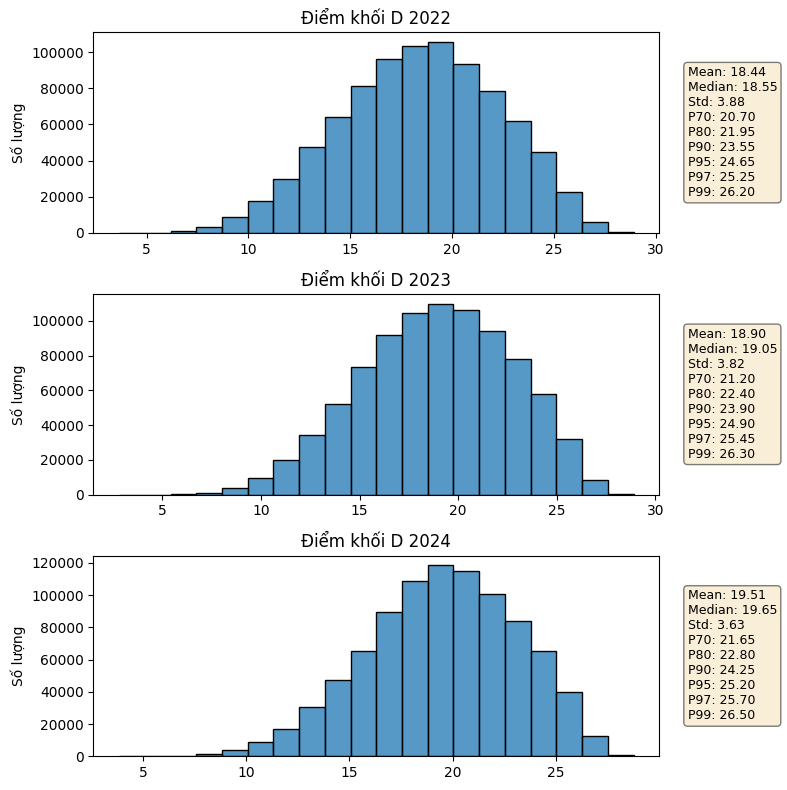

In [ ]:
# Khối D
fig,axes = plt.subplots(3,1,figsize=(8,8))
for i,year in enumerate(year_sorted):
  sns.histplot(df_data[df_data['year']==year]['D'], bins=20, ax=axes[i])
  axes[i].set_title(f'Điểm khối D {year}')
  axes[i].set_xlabel('')
  axes[i].set_ylabel('Số lượng')
  # tính toán các chỉ số thống kê
  year_D = df_data[df_data['year']==year]['D'].dropna()
  mean = year_D.mean()
  median = year_D.median()
  std = year_D.std()
  p70 =  year_D.quantile(0.7)
  p80 =  year_D.quantile(0.8)
  p90 =  year_D.quantile(0.9)
  p95 =  year_D.quantile(0.95)
  p97 =  year_D.quantile(0.97)
  p99 =  year_D.quantile(0.99)
  # hiển thị thông tin thống kê trên biểu đồ
  textstr = f'Mean: {mean:.2f}\nMedian: {median:.2f}\nStd: {std:.2f}\nP70: {p70:.2f}\nP80: {p80:.2f}\nP90: {p90:.2f}\nP95: {p95:.2f}\nP97: {p97:.2f}\nP99: {p99:.2f}'
  prop = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
  axes[i].text(1.05, 0.5, textstr, transform=axes[i].transAxes, fontsize=9, verticalalignment='center', bbox=prop)
plt.tight_layout()
plt.show()

**Năm 2022 (Khối D 2022):**
*   **Điểm trung bình (Mean)**: 18.44
*   **Điểm trung vị (Median)**: 18.55
*   **Độ lệch chuẩn (Std)**: 3.88
*   **Phân bố**: Phổ điểm Khối D năm 2022 có dạng tương đối cân đối, hơi lệch phải nhẹ, với đỉnh phổ biến nằm trong khoảng 18-21 điểm. Có một lượng đáng kể thí sinh đạt điểm cao, thể hiện sự phân hóa tốt.
*   **Nhóm điểm cao**: Các điểm phân vị P90: 23.55, P95: 24.65, P97: 25.25, P99: 26.2. Nhóm thí sinh giỏi đạt điểm cao và có độ phân hóa rõ rệt.

**Năm 2023 (Khối D 2023):**
*   **Điểm trung bình (Mean)**: 18.9
*   **Điểm trung vị (Median)**: 19.05
*   **Độ lệch chuẩn (Std)**: 3.82
*   **Phân bố**: So với năm 2022, phổ điểm có sự dịch chuyển nhẹ về phía điểm cao hơn, phản ánh sự tăng nhẹ của điểm trung bình. Đỉnh phổ biến vẫn nằm trong khoảng 18-21 điểm, nhưng số lượng thí sinh ở các ngưỡng điểm cao có thể tăng lên.
*   **Nhóm điểm cao**: Các điểm phân vị P90: 23.9, P95: 24.9, P97: 25.45, P99: 26.3. Điểm của nhóm thí sinh giỏi cũng tăng nhẹ so với năm 2022.

**Năm 2024 (Khối D 2024):**
*   **Điểm trung bình (Mean)**: 19.51
*   **Điểm trung vị (Median)**: 19.65
*   **Độ lệch chuẩn (Std)**: 3.63
*   **Phân bố**: Phổ điểm năm 2024 duy trì ổn định, tương tự như năm 2023, với điểm trung bình và trung vị gần như không đổi. Đỉnh phổ biến tiếp tục ở khoảng 18-21 điểm, cho thấy sự ổn định trong độ khó của đề thi hoặc mặt bằng chung của thí sinh.
*   **Nhóm điểm cao**: Các điểm phân vị P90: 24.25, P95: 25.20, P97: 25.70, P99: 26.50. Nhóm thí sinh giỏi tiếp tục đạt điểm cao, và sự phân hóa được duy trì.

**Tóm lại về Khối D:**
*   **Điểm trung bình và trung vị** của Khối D cho thấy xu hướng tăng nhẹ từ năm 2022 đến 2023, sau đó ổn định vào năm 2024. Điều này có thể cho thấy độ khó của đề thi Khối D được duy trì ở mức tương đối ổn định, hoặc chất lượng thí sinh có sự cải thiện nhẹ.
*   **Phân bố điểm** của Khối D qua các năm luôn có dạng tương đối cân đối, với đỉnh phổ biến nằm trong khoảng 18-21 điểm, cho thấy đây là một khối thi có sự phân hóa tốt, đặc biệt ở các nhóm điểm cao.
*   **Độ lệch chuẩn** duy trì ở mức khoảng 3.6 - 3.8, cho thấy sự phân tán của điểm số ổn định qua các năm, đảm bảo khả năng phân loại thí sinh trong khối thi này.

## 3.3 Correlation

In [ ]:
df_24 = df_data[df_data['year']==2024].reset_index(drop=True)
df_24.sample(5)

,sbd,toan,ngu_van,ngoai_ngu,vat_li,hoa_hoc,sinh_hoc,lich_su,dia_li,gdcd,year,A,A1,B,C,D
810304,45003781,3.6,5.50,3.8,NaN,NaN,NaN,9.5,8.25,7.50,2024,NaN,NaN,NaN,23.25,12.90
272824,10004763,6.6,7.50,6.6,NaN,NaN,NaN,7.5,8.25,9.50,2024,NaN,NaN,NaN,23.25,20.70
137065,02029240,8.0,6.75,7.2,6.25,6.0,5.25,NaN,NaN,NaN,2024,20.25,21.45,19.25,NaN,21.95
879026,49008794,5.0,5.00,5.2,NaN,NaN,NaN,3.5,5.00,7.50,2024,NaN,NaN,NaN,13.50,15.20
297571,13000129,7.4,8.75,7.8,NaN,NaN,NaN,9.0,8.75,7.75,2024,NaN,NaN,NaN,26.50,23.95


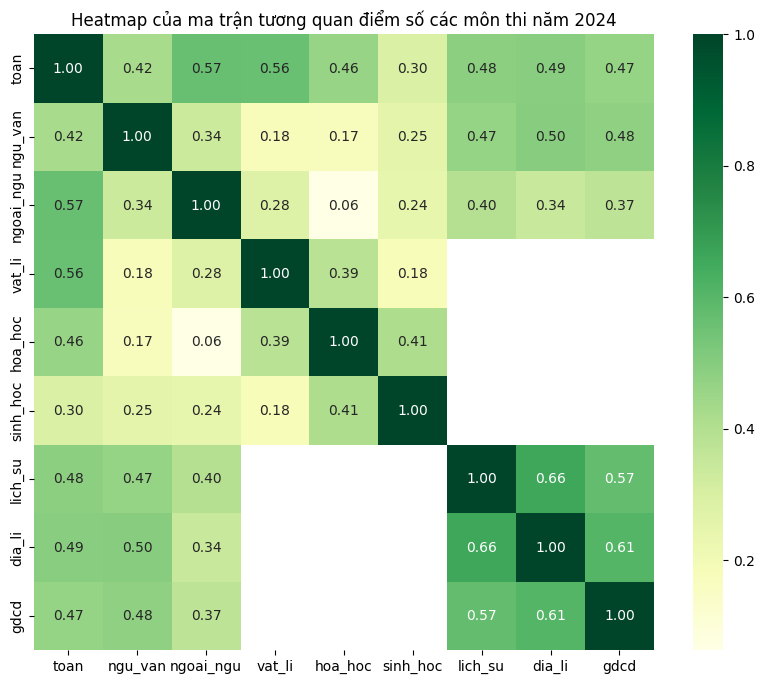

In [ ]:
corr_sub = df_24[subjects].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr_sub, annot=True,cmap='YlGn',fmt=".2f")
plt.title('Heatmap của ma trận tương quan điểm số các môn thi năm 2024')
plt.show()

**Nhận xét chi tiết về Heatmap của ma trận tương quan điểm số các môn thi năm 2024:**

Biểu đồ heatmap thể hiện mối quan hệ tương quan tuyến tính giữa điểm số của các môn thi trong kỳ thi THPT năm 2024. Hệ số tương quan càng gần 1 (màu xanh đậm) thì mối quan hệ thuận chiều càng mạnh, gần -1 thì mối quan hệ nghịch chiều càng mạnh, và gần 0 thì ít có mối quan hệ tuyến tính.

1.  **Tương quan mạnh trong khối Khoa học Tự nhiên (KHTN) và Khoa học Xã hội (KHXH):**
    *   **Vật lí - Hóa học - Sinh học**: Có thể thấy một mối tương quan dương khá mạnh giữa các môn KHTN. Cụ thể:
        *   **Vật lí - Hóa học**: Tương quan 0.39. Đây là một tương quan dương vừa phải, cho thấy những thí sinh giỏi Vật lí thường cũng khá ở Hóa học và ngược lại, phản ánh sự liên quan về tư duy logic và kiến thức cơ bản trong nhóm môn KHTN.
        *   **Hóa học - Sinh học**: Tương quan 0.41. Mối quan hệ tương tự như trên, cho thấy học sinh có khả năng tốt trong nhóm KHTN thường đạt điểm cao ở cả hai môn này.
        *   **Vật lí - Sinh học**: Tương quan 0.18. Tương quan yếu hơn nhiều so với các cặp còn lại trong khối KHTN, cho thấy mặc dù cùng khối, nhưng sự liên kết giữa Vật lí và Sinh học có thể không chặt chẽ bằng Hóa học.
    *   **Lịch sử - Địa lí - GDCD**: Nhóm môn KHXH cho thấy tương quan dương mạnh mẽ:
        *   **Lịch sử - Địa lí**: Tương quan 0.66. Đây là một tương quan dương mạnh, cho thấy những học sinh có kiến thức tốt về Lịch sử thường cũng có điểm cao ở Địa lí, và ngược lại. Điều này phản ánh tư duy phân tích, ghi nhớ và hiểu biết về xã hội có sự liên kết.
        *   **Địa lí - GDCD**: Tương quan 0.61. Tương quan khá mạnh, những thí sinh giỏi Địa lí thường cũng có điểm cao ở GDCD, và ngược lại.
        *   **Lịch sử - GDCD**: Tương quan 0.57. Tương quan tương đối mạnh, tương tự các cặp còn lại trong nhóm KHXH.

2.  **Môn Ngoại ngữ:**
    *   **Ngoại ngữ - Toán**: Tương quan 0.57. Đây là một trong những tương quan mạnh nhất, cho thấy thí sinh có năng lực tốt ở môn Toán cũng thường có điểm cao ở Ngoại ngữ và ngược lại. Điều này có thể phản ánh khả năng tư duy logic và học tốt các môn đòi hỏi sự rèn luyện bài bản.
    *   **Ngoại ngữ - Ngữ văn**: Tương quan 0.34. Tương quan dương ở mức trung bình, cho thấy một phần học sinh giỏi Ngữ văn cũng có khả năng học tốt Ngoại ngữ, và ngược lại.
    *   **Ngoại ngữ - các môn KHTN/KHXH**: Tương quan giữa Ngoại ngữ với các môn KHTN (Vật lí, Hóa học, Sinh học) và KHXH (Lịch sử, Địa lí, GDCD) thường yếu hơn, dao động từ 0.06 đến 0.28. Điều này cho thấy Ngoại ngữ có tính chất độc lập hơn hoặc đòi hỏi bộ kỹ năng khác biệt so với các môn còn lại.

3.  **Môn Toán:**
    *   **Toán - Ngoại ngữ**: Như đã đề cập, đây là một cặp tương quan mạnh (0.57).
    *   **Toán - Vật lí**: Tương quan 0.56. Tương quan mạnh mẽ, phản ánh sự liên kết chặt chẽ về kiến thức và tư duy giữa hai môn này, vốn là nền tảng của khối A.
    *   **Toán - Hóa học**: Tương quan 0.46. Tương quan dương đáng kể, thí sinh giỏi Toán thường cũng giỏi Hóa học.
    *   **Toán - Ngữ văn**: Tương quan 0.42. Tương quan dương vừa phải, cho thấy khả năng học tốt cả hai môn này thường đi đôi với nhau.
    *   **Toán - Sinh học**: Tương quan 0.30. Tương quan yếu hơn so với Vật lí và Hóa học.

4.  **Môn Ngữ văn:**
    *   **Ngữ văn - Lịch sử**: Tương quan 0.47. Tương quan dương mạnh, thể hiện học sinh có năng khiếu về các môn xã hội thường đạt điểm tốt cả hai môn.
    *   **Ngữ văn - Địa lí**: Tương quan 0.5. Tương quan mạnh mẽ tương tự với Lịch sử.
    *   **Ngữ văn - GDCD**: Tương quan 0.48. Tương quan rất mạnh, cho thấy sự đồng nhất về khả năng giữa Ngữ văn và GDCD.

**Kết luận chung:**

*   **Sự phân hóa rõ rệt theo khối thi**: Các môn trong cùng một khối (KHTN: Vật lí, Hóa học, Sinh học; KHXH: Lịch sử, Địa lí, GDCD) thường có mối tương quan dương mạnh hơn so với các môn khác khối. Điều này khẳng định xu hướng học sinh có thế mạnh và tập trung vào một khối kiến thức nhất định.
*   **Toán và Ngoại ngữ có sự tương quan rộng**: Toán và Ngoại ngữ không chỉ tương quan tốt với các môn trong khối của chúng mà còn có tương quan đáng kể với một số môn khác, cho thấy chúng có thể là những môn nền tảng quan trọng, đòi hỏi năng lực tư duy tổng quát.
*   **GDCD có tương quan mạnh với các môn xã hội khác**: Điều này cho thấy sự đồng bộ trong năng lực học các môn về kiến thức xã hội và công dân.

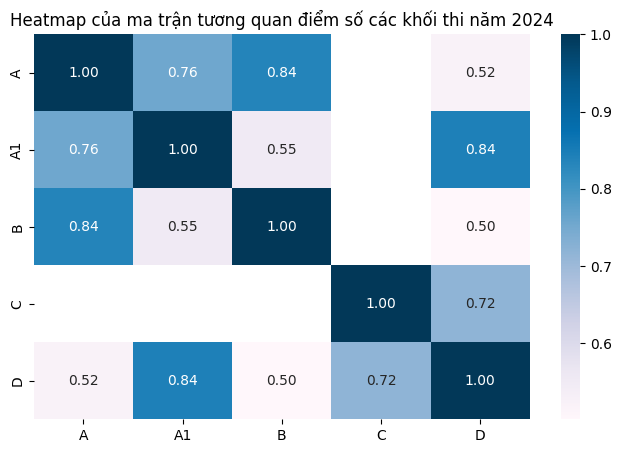

In [ ]:
# tương quan giữa các khối thi
corr_comb = df_24[combinations].corr()
plt.figure(figsize=(8,5))
sns.heatmap(corr_comb, annot=True,cmap='PuBu',fmt=".2f")
plt.title(f'Heatmap của ma trận tương quan điểm số các khối thi năm 2024')
plt.show()

**Nhận xét chi tiết về Heatmap của ma trận tương quan điểm số các khối thi năm 2024:**

Biểu đồ heatmap này thể hiện mối quan hệ tương quan tuyến tính giữa tổng điểm của các khối thi chính (A, A1, B, C, D) trong kỳ thi THPT năm 2024. Hệ số tương quan càng gần 1 (màu xanh đậm) thì mối quan hệ thuận chiều càng mạnh, và gần 0 thì ít có mối quan hệ tuyến tính.

1.  **Tương quan mạnh nhất: Khối A1 và Khối D (0.84)**
    *   Đây là mối tương quan mạnh nhất trên biểu đồ. Cả hai khối này đều có môn Toán và Ngoại ngữ là các môn chung. Mối tương quan rất cao này cho thấy thí sinh đạt điểm cao ở khối A1 (Toán, Vật lí, Ngoại ngữ) cũng có xu hướng đạt điểm cao ở khối D (Toán, Ngữ văn, Ngoại ngữ), và ngược lại. Điều này phản ánh rõ ràng tầm quan trọng của Toán và Ngoại ngữ trong việc đánh giá năng lực tổng thể của học sinh, cũng như sự đồng nhất trong nhóm thí sinh có thế mạnh ở hai môn này.

2.  **Tương quan mạnh giữa Khối A và Khối B (0.84)**
    *   Khối A (Toán, Vật lí, Hóa học) và Khối B (Toán, Hóa học, Sinh học) có mối tương quan rất mạnh. Điều này là hoàn toàn hợp lý vì cả hai khối đều có môn Toán và Hóa học là môn chung, đồng thời đều thuộc nhóm Khoa học Tự nhiên. Học sinh có nền tảng tốt về tư duy logic và kiến thức KHTN thường làm tốt ở cả hai khối này.

3.  **Tương quan mạnh giữa Khối A và Khối A1 (0.76)**
    *   Khối A và Khối A1 có một môn chung là Toán và một môn có tính chất tương đồng là Vật lí. Mối tương quan mạnh này cho thấy thí sinh giỏi Toán và Vật lí thường có khả năng tốt ở cả hai khối, dù khối A1 có thêm Ngoại ngữ và khối A có thêm Hóa học.

4.  **Tương quan mạnh giữa Khối C và Khối D (0.72)**
    *   Khối C (Ngữ văn, Lịch sử, Địa lí) và Khối D (Toán, Ngữ văn, Ngoại ngữ) có chung môn Ngữ văn. Mối tương quan mạnh này cho thấy thí sinh có năng lực tốt về Ngữ văn thường cũng có khả năng tốt ở các môn xã hội khác (trong khối C) và có khả năng học tốt Ngoại ngữ (trong khối D). Điều này gợi ý rằng năng lực ngôn ngữ và tư duy xã hội có sự liên kết nhất định.

5.  **Tương quan yếu hơn với các khối khác:**
    *   Mối tương quan giữa các khối KHTN (A, A1, B) và khối KHXH (C) là NaN (Not a Number) trong ma trận tương quan này. Điều này xảy ra khi không có đủ thí sinh tham gia đủ các môn trong cả hai khối để tính toán tương quan, hoặc có quá nhiều giá trị NaN trong các cột tương ứng, đặc biệt là khi các thí sinh thường chỉ chọn thi một trong hai tổ hợp Khoa học Tự nhiên hoặc Khoa học Xã hội. Tuy nhiên, nếu nhìn vào heatmap nhỏ hơn, có thể thấy mối quan hệ giữa khối A và C là yếu.
    *   Khối B và Khối D có tương quan ở mức 0.50. Dù có môn Toán chung, nhưng sự khác biệt về các môn còn lại (Hóa học, Sinh học so với Ngữ văn, Ngoại ngữ) làm giảm mức độ tương quan so với các cặp khối KHTN hoặc KHXH với nhau.

**Kết luận chung:**

*   **Phân hóa rõ ràng theo định hướng ban đầu**: Biểu đồ heatmap cho thấy các khối thi có các môn học cùng nhóm (KHTN hoặc KHXH) có mức độ tương quan điểm số rất cao. Điều này phản ánh rằng học sinh thường có thế mạnh và tập trung ôn luyện theo định hướng khối thi của mình.
*   **Toán và Ngoại ngữ là các môn nền tảng**: Sự tương quan mạnh giữa khối A1 và D, cùng với mối liên hệ của Toán và Ngoại ngữ với các khối khác, cho thấy đây là hai môn có tính chất nền tảng, đòi hỏi năng lực tư duy tổng quát và kỹ năng học tập tốt.
*   **Sự độc lập giữa các nhóm khối lớn**: Mức độ tương quan thấp hoặc không xác định giữa khối KHTN và KHXH nhấn mạnh sự phân hóa trong lựa chọn môn học và năng lực của thí sinh giữa hai nhóm ngành lớn này.

## 3.4 Location

In [ ]:
province_map = {
    '01': 'THÀNH PHỐ HÀ NỘI',
    '02': 'THÀNH PHỐ HỒ CHÍ MINH',
    '03': 'THÀNH PHỐ HẢI PHÒNG',
    '04': 'THÀNH PHỐ ĐÀ NẴNG',
    '05': 'TỈNH HÀ GIANG',
    '06': 'TỈNH CAO BẰNG',
    '07': 'TỈNH LAI CHÂU',
    '08': 'TỈNH LÀO CAI',
    '09': 'TỈNH TUYÊN QUANG',
    '10': 'TỈNH LẠNG SƠN',
    '11': 'TỈNH BẮC KẠN',
    '12': 'TỈNH THÁI NGUYÊN',
    '13': 'TỈNH YÊN BÁI',
    '14': 'TỈNH SƠN LA',
    '15': 'TỈNH PHÚ THỌ',
    '16': 'TỈNH VĨNH PHÚC',
    '17': 'TỈNH QUẢNG NINH',
    '18': 'TỈNH BẮC GIANG',
    '19': 'TỈNH BẮC NINH',
    '21': 'TỈNH HẢI DƯƠNG',
    '22': 'TỈNH HƯNG YÊN',
    '23': 'TỈNH HÒA BÌNH',
    '24': 'TỈNH HÀ NAM',
    '25': 'TỈNH NAM ĐỊNH',
    '26': 'TỈNH THÁI BÌNH',
    '27': 'TỈNH NINH BÌNH',
    '28': 'TỈNH THANH HÓA',
    '29': 'TỈNH NGHỆ AN',
    '30': 'TỈNH HÀ TĨNH',
    '31': 'TỈNH QUẢNG BÌNH',
    '32': 'TỈNH QUẢNG TRỊ',
    '33': 'TỈNH THỪA THIÊN - HUẾ',
    '34': 'TỈNH QUẢNG NAM',
    '35': 'TỈNH QUẢNG NGÃI',
    '36': 'TỈNH KON TUM',
    '37': 'TỈNH BÌNH ĐỊNH',
    '38': 'TỈNH GIA LAI',
    '39': 'TỈNH PHÚ YÊN',
    '40': 'TỈNH ĐẮK LẮK',
    '41': 'TỈNH KHÁNH HÒA',
    '42': 'TỈNH LÂM ĐỒNG',
    '43': 'TỈNH BÌNH PHƯỚC',
    '44': 'TỈNH BÌNH DƯƠNG',
    '45': 'TỈNH NINH THUẬN',
    '46': 'TỈNH TÂY NINH',
    '47': 'TỈNH BÌNH THUẬN',
    '48': 'TỈNH ĐỒNG NAI',
    '49': 'TỈNH LONG AN',
    '50': 'TỈNH ĐỒNG THÁP',
    '51': 'TỈNH AN GIANG',
    '52': 'TỈNH BÀ RỊA – VŨNG TÀU',
    '53': 'TỈNH TIỀN GIANG',
    '54': 'TỈNH KIÊN GIANG',
    '55': 'THÀNH PHỐ CẦN THƠ',
    '56': 'TỈNH BẾN TRE',
    '57': 'TỈNH VĨNH LONG',
    '58': 'TỈNH TRÀ VINH',
    '59': 'TỈNH SÓC TRĂNG',
    '60': 'TỈNH BẠC LIÊU',
    '61': 'TỈNH CÀ MAU',
    '62': 'TỈNH ĐIỆN BIÊN',
    '63': 'TỈNH ĐĂK NÔNG',
    '64': 'TỈNH HẬU GIANG'
}

In [ ]:
df_24['ma_hd'] = df_24['sbd'].str[:2]
df_24['tinh_thanh'] = df_24['ma_hd'].map(province_map)

In [ ]:
df_24.sample(5)

,sbd,toan,ngu_van,ngoai_ngu,vat_li,hoa_hoc,sinh_hoc,lich_su,dia_li,gdcd,year,A,A1,B,C,D,ma_hd,tinh_thanh
372884,18004504,3.6,6.00,4.0,7.0,6.75,3.75,NaN,NaN,NaN,2024,17.35,14.6,14.1,NaN,13.60,18,TỈNH BẮC GIANG
409302,21001540,7.8,8.50,4.4,NaN,NaN,NaN,7.50,8.50,9.00,2024,NaN,NaN,NaN,24.50,20.70,21,TỈNH HẢI DƯƠNG
340212,16005133,6.4,7.50,4.4,NaN,NaN,NaN,9.50,9.75,8.00,2024,NaN,NaN,NaN,26.75,18.30,16,TỈNH VĨNH PHÚC
417313,21009573,7.0,9.25,6.6,NaN,NaN,NaN,7.75,9.00,8.25,2024,NaN,NaN,NaN,26.00,22.85,21,TỈNH HẢI DƯƠNG
447269,22016185,6.2,5.75,4.6,NaN,NaN,NaN,7.50,8.50,9.00,2024,NaN,NaN,NaN,21.75,16.55,22,TỈNH HƯNG YÊN


In [ ]:
# thống kê số lượng thí sinh mỗi tỉnh
num_candidates_per_province = df_24['tinh_thanh'].value_counts()

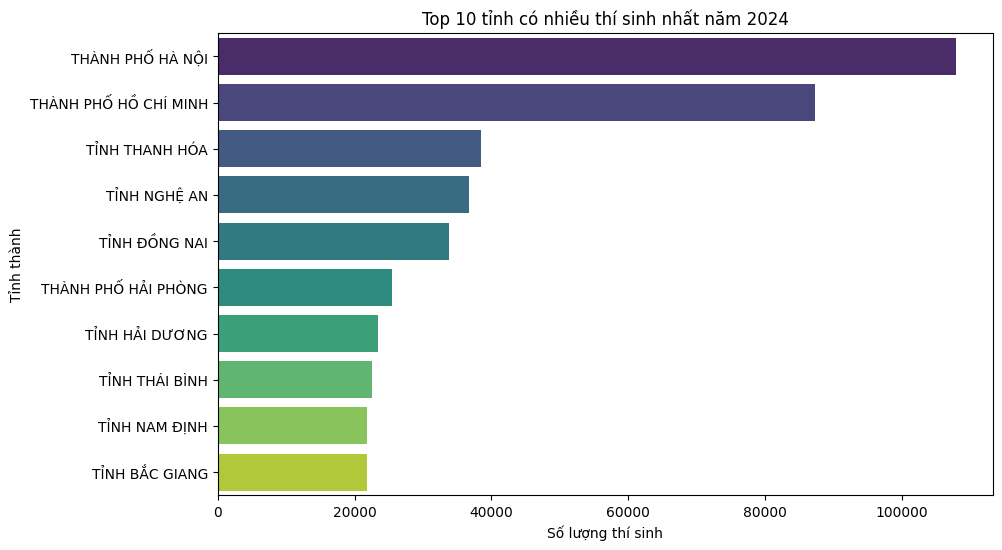

In [ ]:
top_10_provinces = num_candidates_per_province.head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_10_provinces.values, y=top_10_provinces.index, palette='viridis', hue=top_10_provinces.index, legend=False)
plt.title('Top 10 tỉnh có nhiều thí sinh nhất năm 2024')
plt.xlabel('Số lượng thí sinh')
plt.ylabel('Tỉnh thành')
plt.show()

Biểu đồ cột này thể hiện 10 tỉnh/thành phố có số lượng thí sinh tham gia kỳ thi THPT Quốc gia năm 2024 đông nhất. Dựa vào biểu đồ, chúng ta có thể thấy rõ sự chênh lệch đáng kể về quy mô thí sinh giữa các địa phương:

1.  **Thành phố Hà Nội và Thành phố Hồ Chí Minh dẫn đầu**: Hai thành phố lớn nhất cả nước là Hà Nội (107.867 thí sinh) và Hồ Chí Minh (87.322 thí sinh) có số lượng thí sinh vượt trội so với các tỉnh còn lại. Điều này là điều dễ hiểu vì đây là hai trung tâm kinh tế, văn hóa, giáo dục lớn nhất, tập trung dân cư đông đúc và nhiều trường học.

2.  **Sự phân tầng rõ rệt**: Có một khoảng cách đáng kể giữa hai thành phố dẫn đầu và các tỉnh tiếp theo. Tỉnh Thanh Hóa đứng thứ ba với 38.532 thí sinh, chưa bằng một nửa số lượng của TP. Hồ Chí Minh. Điều này cho thấy sự phân bố không đồng đều về dân số và quy mô giáo dục giữa các vùng miền.

3.  **Các tỉnh có dân số đông và truyền thống hiếu học**: Các tỉnh như Thanh Hóa, Nghệ An (36.729 thí sinh), Đồng Nai (33.800 thí sinh), Hải Phòng (25.530 thí sinh) cũng nằm trong top đầu, phản ánh đặc điểm dân số đông và truyền thống chú trọng giáo dục ở những địa phương này.

4.  **Tập trung ở khu vực Đồng bằng sông Hồng và duyên hải miền Trung**: Trong top 10, nhiều tỉnh thuộc khu vực Đồng bằng sông Hồng (Hà Nội, Hải Phòng, Hải Dương, Thái Bình, Nam Định) và duyên hải miền Trung (Thanh Hóa, Nghệ An) xuất hiện, cho thấy đây là những vùng có mật độ dân số cao và hệ thống giáo dục phát triển.

5.  **Ý nghĩa**: Dữ liệu này rất quan trọng cho Bộ Giáo dục và Đào tạo cũng như các sở giáo dục địa phương trong việc lập kế hoạch tổ chức thi, phân bổ nguồn lực, và đánh giá quy mô giáo dục ở từng khu vực. Nó cũng ảnh hưởng đến chỉ tiêu tuyển sinh của các trường đại học, đặc biệt là các trường ở các thành phố lớn.

**Tóm lại**: Biểu đồ cho thấy rõ quy mô lớn của kỳ thi tại các thành phố trung tâm và các tỉnh đông dân. Sự chênh lệch về số lượng thí sinh giữa các địa phương là một yếu tố quan trọng cần được cân nhắc trong chính sách giáo dục và tuyển sinh.

In [ ]:
# điểm trung bình các môn mỗi tỉnh
mean_scores_per_province = df_24.groupby('tinh_thanh')[subjects].mean()
mean_scores_per_province

,toan,ngu_van,ngoai_ngu,vat_li,hoa_hoc,sinh_hoc,lich_su,dia_li,gdcd
tinh_thanh,,,,,,,,,
THÀNH PHỐ CẦN THƠ,6.492319,6.959842,5.434775,6.444484,6.814845,6.551372,6.620477,7.180020,8.228692
THÀNH PHỐ HÀ NỘI,6.747195,7.758938,6.204682,6.806534,6.219496,5.912199,6.617198,7.057476,8.121561
THÀNH PHỐ HẢI PHÒNG,6.794488,7.998668,5.999775,7.018733,6.668886,6.416166,6.850439,7.576897,8.607108
THÀNH PHỐ HỒ CHÍ MINH,6.983628,6.654757,6.734718,6.340175,6.493727,6.220585,6.621620,7.201315,8.308814
THÀNH PHỐ ĐÀ NẴNG,6.615767,6.565447,6.106048,6.627614,6.383268,5.656873,6.037089,6.714544,7.827887
...,...,...,...,...,...,...,...,...,...
TỈNH ĐIỆN BIÊN,5.278871,6.572146,4.131750,6.258767,6.637443,6.120638,6.321724,7.043443,7.572263
TỈNH ĐĂK NÔNG,5.839483,6.511106,4.348293,6.213977,6.344888,5.968096,6.345188,6.931709,7.757531
TỈNH ĐẮK LẮK,5.801205,6.583557,4.653281,6.248925,6.431844,5.831457,5.968347,6.616193,7.611599


In [ ]:
# top 5 tỉnh có điểm trung bình môn toán cao nhất
top_5_toan = mean_scores_per_province.sort_values(by='toan', ascending=False).head(5)
top_5_toan['toan'].round(2)

,toan
tinh_thanh,
TỈNH NAM ĐỊNH,7.26
TỈNH BÌNH DƯƠNG,7.13
TỈNH BẮC NINH,7.00
THÀNH PHỐ HỒ CHÍ MINH,6.98
TỈNH VĨNH PHÚC,6.95


In [ ]:
# top 5 tỉnh có điểm trung bình môn văn cao nhất
top_5_van = mean_scores_per_province.sort_values(by='ngu_van', ascending=False).head(5)
top_5_van['ngu_van'].round(2)

,ngu_van
tinh_thanh,
TỈNH NINH BÌNH,8.17
TỈNH TRÀ VINH,8.09
TỈNH HÀ NAM,8.05
TỈNH NAM ĐỊNH,8.05
TỈNH NGHỆ AN,8.04


In [ ]:
# top 5 tỉnh có điểm trung bình môn ngoại ngữ cao nhất
top_5_nn = mean_scores_per_province.sort_values(by='ngoai_ngu', ascending=False).head(5)
top_5_nn['ngoai_ngu'].round(2)

,ngoai_ngu
tinh_thanh,
THÀNH PHỐ HỒ CHÍ MINH,6.73
TỈNH BÌNH DƯƠNG,6.65
TỈNH BÀ RỊA – VŨNG TÀU,6.22
THÀNH PHỐ HÀ NỘI,6.20
THÀNH PHỐ ĐÀ NẴNG,6.11


In [ ]:
# top 5 tỉnh có điểm trung bình môn lí cao nhất
top_5_li = mean_scores_per_province.sort_values(by='vat_li', ascending=False).head(5)
top_5_li['vat_li'].round(2)

,vat_li
tinh_thanh,
TỈNH VĨNH PHÚC,7.49
TỈNH BẮC NINH,7.46
TỈNH NAM ĐỊNH,7.24
TỈNH HÀ TĨNH,7.23
TỈNH NINH BÌNH,7.22


In [ ]:
# top 5 tỉnh có điểm trung bình môn hóa cao nhất
top_5_hoa = mean_scores_per_province.sort_values(by='hoa_hoc', ascending=False).head(5)
top_5_hoa['hoa_hoc'].round(2)

,hoa_hoc
tinh_thanh,
TỈNH TUYÊN QUANG,7.52
TỈNH HÀ TĨNH,7.33
TỈNH NAM ĐỊNH,7.28
TỈNH VĨNH PHÚC,7.25
TỈNH NGHỆ AN,7.20


In [ ]:
# top 5 tỉnh có điểm trung bình môn sinh cao nhất
top_5_sinh = mean_scores_per_province.sort_values(by='sinh_hoc', ascending=False).head(5)
top_5_sinh['sinh_hoc'].round(2)

,sinh_hoc
tinh_thanh,
TỈNH TUYÊN QUANG,7.32
TỈNH VĨNH LONG,7.01
TỈNH VĨNH PHÚC,7.00
TỈNH NINH BÌNH,6.84
TỈNH BÌNH DƯƠNG,6.77


In [ ]:
# top 5 tỉnh có điểm trung bình môn sử cao nhất
top_5_su = mean_scores_per_province.sort_values(by='lich_su', ascending=False).head(5)
top_5_su['lich_su'].round(2)

,lich_su
tinh_thanh,
TỈNH VĨNH PHÚC,7.44
TỈNH NINH BÌNH,7.28
TỈNH NAM ĐỊNH,7.14
TỈNH BÌNH DƯƠNG,7.10
TỈNH PHÚ THỌ,7.08


In [ ]:
# top 5 tỉnh có điểm trung bình môn địa cao nhất
top_5_dia = mean_scores_per_province.sort_values(by='dia_li', ascending=False).head(5)
top_5_dia['dia_li'].round(2)

,dia_li
tinh_thanh,
TỈNH VĨNH PHÚC,8.07
TỈNH NINH BÌNH,8.00
TỈNH NAM ĐỊNH,7.93
TỈNH BÌNH DƯƠNG,7.80
TỈNH PHÚ THỌ,7.71


In [ ]:
# top 5 tỉnh có điểm trung bình môn GDCD cao nhất
top_5_gdcd = mean_scores_per_province.sort_values(by='gdcd', ascending=False).head(5)
top_5_gdcd['gdcd'].round(2)

,gdcd
tinh_thanh,
TỈNH VĨNH PHÚC,8.96
TỈNH NAM ĐỊNH,8.80
TỈNH BÌNH DƯƠNG,8.78
TỈNH NINH BÌNH,8.76
TỈNH PHÚ THỌ,8.64


# 4.Machine learning